# Livrable 3 — Captioning d'Image (COCO 2017)
## Projet DS Leyenda — TouNum

---

Ce livrable met en oeuvre un pipeline complet de **generation automatique de descriptions**
(image captioning) sur le dataset COCO 2017.

```
Images COCO 2017  -->  Encodeur CNN (InceptionV3)  -->  Representation visuelle
                                                               |
                        Tokenisation des captions              |
                                |                              v
                       Pipeline tf.data  <----------  CNN + RNN / Transformer
                                                               |
                        Interface interactive  <--  Evaluation & comparaison
```

| Partie | Contenu |
|--------|---------|
| **1. Donnees** | Chargement COCO 2017, exploration, statistiques |
| **2. Pretraitement images** | InceptionV3, extraction features, cache disque |
| **3. Pretraitement texte** | Tokenisation, vocabulaire, padding |
| **4. Split & Pipeline** | Train/Val/Test 80/10/10, tf.data |
| **5. Modele CNN + RNN** | CNN Encoder, Attention Bahdanau, GRU Decoder |
| **6. Modele CNN + Transformer** | Decoder Transformer, cross-attention |
| **7. Comparaison** | BLEU, courbes, exemples qualitatifs |
| **8. Interface Interactive** | Upload image -> caption (RNN ou Transformer) |

---
## 0. Imports & Configuration

In [1]:
# Installations supplémentaires

%pip install tqdm nltk


[notice] A new release of pip is available: 23.2.1 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt
import numpy as np
import collections
import random
import json
import os
import time
import pickle
from PIL import Image
from tqdm import tqdm

print(f'TensorFlow {tf.__version__}')
print(f'GPU disponible : {len(tf.config.list_physical_devices("GPU")) > 0}')

2026-06-08 11:03:04.256913: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-08 11:03:04.257021: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-08 11:03:04.258511: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-08 11:03:04.455865: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow 2.14.0
GPU disponible : True


2026-06-08 11:03:09.115085: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:09:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-08 11:03:09.161604: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:09:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-08 11:03:09.161664: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:09:00.0/numa_node
Your kernel may have been built without NUMA support.


In [3]:
# ============================================================
# CONFIGURATION GLOBALE
# ============================================================
ANNOTATION_FILE = 'notebooks/data_3/annotations/captions_train2017.json'
IMAGE_PATH      = 'notebooks/data_3/train2017/'
NUM_IMAGES      = None      # None = 118 287 images (run complet)
TOP_K           = 7000      # vocabulaire elargi pour 118K images

# --- Architecture (optimisee) ---
EMBEDDING_DIM = 512         # 256 -> 512 : representations plus riches
UNITS         = 512         # GRU hidden units
NUM_HEADS     = 8           # 4 -> 8 heads (512/8 = 64 par tete)
FF_DIM        = 2048        # 1024 -> 2048 : FFN plus expressif
NUM_LAYERS_TR = 4           # 3 -> 4 blocs Transformer
DROPOUT_TR    = 0.2         # 0.3 -> 0.2 : moins d overfitting sur 118K

# --- Entrainement ---
BATCH_SIZE       = 128
BUFFER_SIZE      = 1000
EPOCHS_RNN       = 20
EPOCHS_TR        = 30       # plus d epochs pour convergence
WARMUP_STEPS     = 8000     # 4000 -> 8000 : adapte a 118K images
LABEL_SMOOTHING  = 0.1
GRAD_CLIP        = 1.0
WEIGHT_DECAY     = 1e-4      # AdamW regularization
PATIENCE         = 5         # early stopping patience

# --- Inference ---
BEAM_SIZE = 5

# --- Precision mixte fp16 — decommentez si OOM (GPU 8GB) ---
tf.keras.mixed_precision.set_global_policy('mixed_float16')

# IMPORTANT : si architecture ou NUM_IMAGES change, supprimer
#             les anciens checkpoints avant de relancer.

# --- Sauvegardes ---
CHECKPOINT_DIR_RNN = 'notebooks/checkpoints_rnn/'
CHECKPOINT_DIR_TR  = 'notebooks/checkpoints_transformer/'
TOKENIZER_PATH     = 'notebooks/tokenizer_coco.pkl'

SEED = 42
import random, numpy as np, tensorflow as tf
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print('Configuration chargee.')

INFO:tensorflow:Mixed precision compatibility check (mixed_float16): OK
Your GPU will likely run quickly with dtype policy mixed_float16 as it has compute capability of at least 7.0. Your GPU: NVIDIA GeForce RTX 2080, compute capability 7.5
Configuration chargee.


2026-06-08 11:03:09.215217: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:09:00.0/numa_node
Your kernel may have been built without NUMA support.


---
## 0b. Reprise — Modeles deja entraines

Si vos modeles sont **deja entraines** et sauvegardés, vous pouvez sauter
toutes les cellules d'entrainement et aller directement a la comparaison / GUI.

### Cellules a executer dans l'ordre (rapide, sans GPU)

```
1. cell-imports          (imports)
2. cell-config           (hyperparametres)
3. cell-cnn-encoder      (definition classe CNN_Encoder)
4. cell-attention        (definition classe BahdanauAttention)
5. cell-rnn-decoder      (definition classe RNN_Decoder + instanciation)
6. cell-transformer-arch (definition classes Transformer + instanciation)
7. cell-reprise          (CETTE CELLULE : charge tout depuis le disque)
```

Puis executer directement **cell-compare**, **cell-gui**, ou **cell-blip-load/eval**.

### Fichiers requis sur le disque

| Fichier | Contenu | Genere par |
|---------|---------|------------|
| `tokenizer_coco.pkl` | Tokenizer + max_length | cell-tokenizer |
| `test_split.pkl` | img_name_test + cap_test | cell-split |
| `checkpoints_rnn/` | Poids RNN | cell-rnn-train |
| `checkpoints_transformer/` | Poids Transformer | cell-transformer-train |
| `history_rnn.json` | Courbes RNN | cell-rnn-train |
| `history_tr.json` | Courbes Transformer | cell-transformer-train |

---
## 1. Chargement et Exploration des Donnees

### Dataset COCO 2017

**COCO** (Common Objects in Context) est le benchmark standard du captioning.

| Statistique | Valeur |
|-------------|--------|
| Images train2017 | 118 287 |
| Captions par image | ~5 (annotations humaines) |
| Total captions | ~591 000 |
| Format | JSON (annotations) + JPEG (images) |

Chaque annotation JSON a la forme :
```json
{"image_id": 391895, "caption": "A man riding a horse in a field."}
```

### Tokens speciaux

| Token | Role |
|-------|------|
| `<start>` | Debut de chaque caption (entree decodeur) |
| `<end>` | Fin (condition d'arret de la generation) |
| `<unk>` | Mots hors-vocabulaire |
| `<pad>` | Padding pour egaliser les longueurs |

In [4]:
with open(ANNOTATION_FILE, 'r') as f:
    annotations = json.load(f)

print(f'Nombre d annotations : {len(annotations["annotations"])}')
print(f'Exemple : {annotations["annotations"][0]}')

# Grouper les captions par chemin d image
image_path_to_caption = collections.defaultdict(list)
for val in annotations['annotations']:
    caption    = '<start> ' + val['caption'] + ' <end>'
    image_path = IMAGE_PATH + '%012d.jpg' % val['image_id']
    image_path_to_caption[image_path].append(caption)

# Selectionner NUM_IMAGES images aleatoirement
all_image_paths = list(image_path_to_caption.keys())
random.shuffle(all_image_paths)
selected_paths  = all_image_paths if NUM_IMAGES is None else all_image_paths[:NUM_IMAGES]

# Construire les listes (image_path, caption)
all_captions, all_img_paths = [], []
for image_path in selected_paths:
    captions = image_path_to_caption[image_path]
    all_captions.extend(captions)
    all_img_paths.extend([image_path] * len(captions))

print(f'Images selectionnees    : {len(selected_paths):,}')
print(f'Paires (image, caption) : {len(all_captions):,}')
print(f'Captions / image (moy.) : {len(all_captions)/len(selected_paths):.1f}')

Nombre d annotations : 591753
Exemple : {'image_id': 203564, 'id': 37, 'caption': 'A bicycle replica with a clock as the front wheel.'}
Images selectionnees    : 118,287
Paires (image, caption) : 591,753
Captions / image (moy.) : 5.0


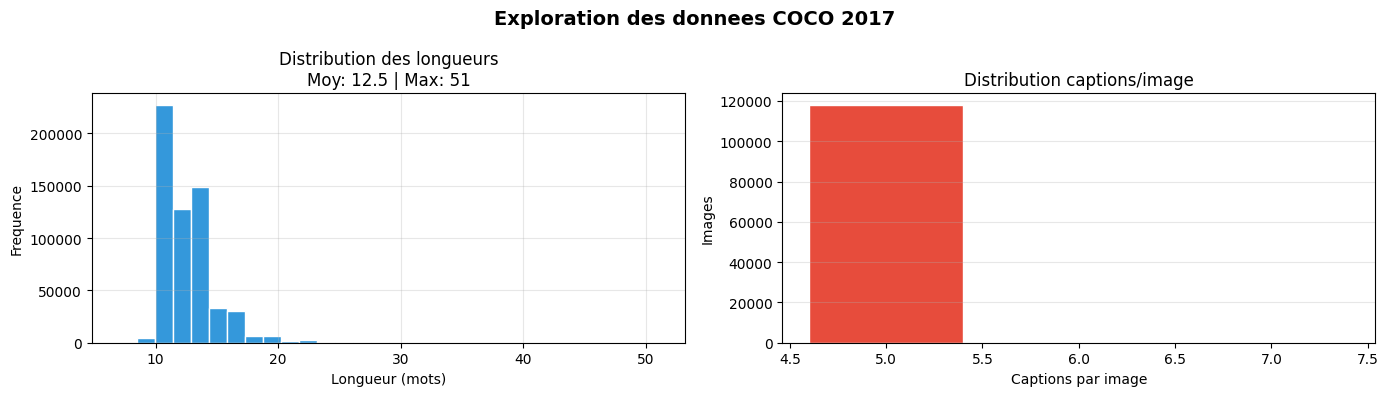

=== Exemples ===

Image : 000000519945.jpg
  <start> a small boats in a body of water  <end>
  <start> a large starcraft boat, on a lake, with a flag that reads "ski life" on it. <end>

Image : 000000305075.jpg
  <start> A white spa-like bathroom with towels and flowers. <end>
  <start> A series of four pictures of a bathroom. <end>

Image : 000000191561.jpg
  <start> People splitting up a box of mixed doughnuts. <end>
  <start> He has his pinky finger on the donut that he wants. <end>


In [5]:
caption_lengths = [len(c.split()) for c in all_captions]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Exploration des donnees COCO 2017', fontsize=14, fontweight='bold')

axes[0].hist(caption_lengths, bins=30, color='#3498db', edgecolor='white')
axes[0].set_xlabel('Longueur (mots)'); axes[0].set_ylabel('Frequence')
axes[0].set_title(
    f'Distribution des longueurs\n'
    f'Moy: {np.mean(caption_lengths):.1f} | Max: {max(caption_lengths)}'
)
axes[0].grid(alpha=0.3)

from collections import Counter
caps_per_image = [len(image_path_to_caption[p]) for p in selected_paths]
cnt = Counter(caps_per_image)
axes[1].bar(cnt.keys(), cnt.values(), color='#e74c3c', edgecolor='white')
axes[1].set_xlabel('Captions par image'); axes[1].set_ylabel('Images')
axes[1].set_title('Distribution captions/image')
axes[1].grid(alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

print('=== Exemples ===')
for i in range(3):
    img_p = selected_paths[i]
    print(f'\nImage : {os.path.basename(img_p)}')
    for cap in image_path_to_caption[img_p][:2]:
        print(f'  {cap}')

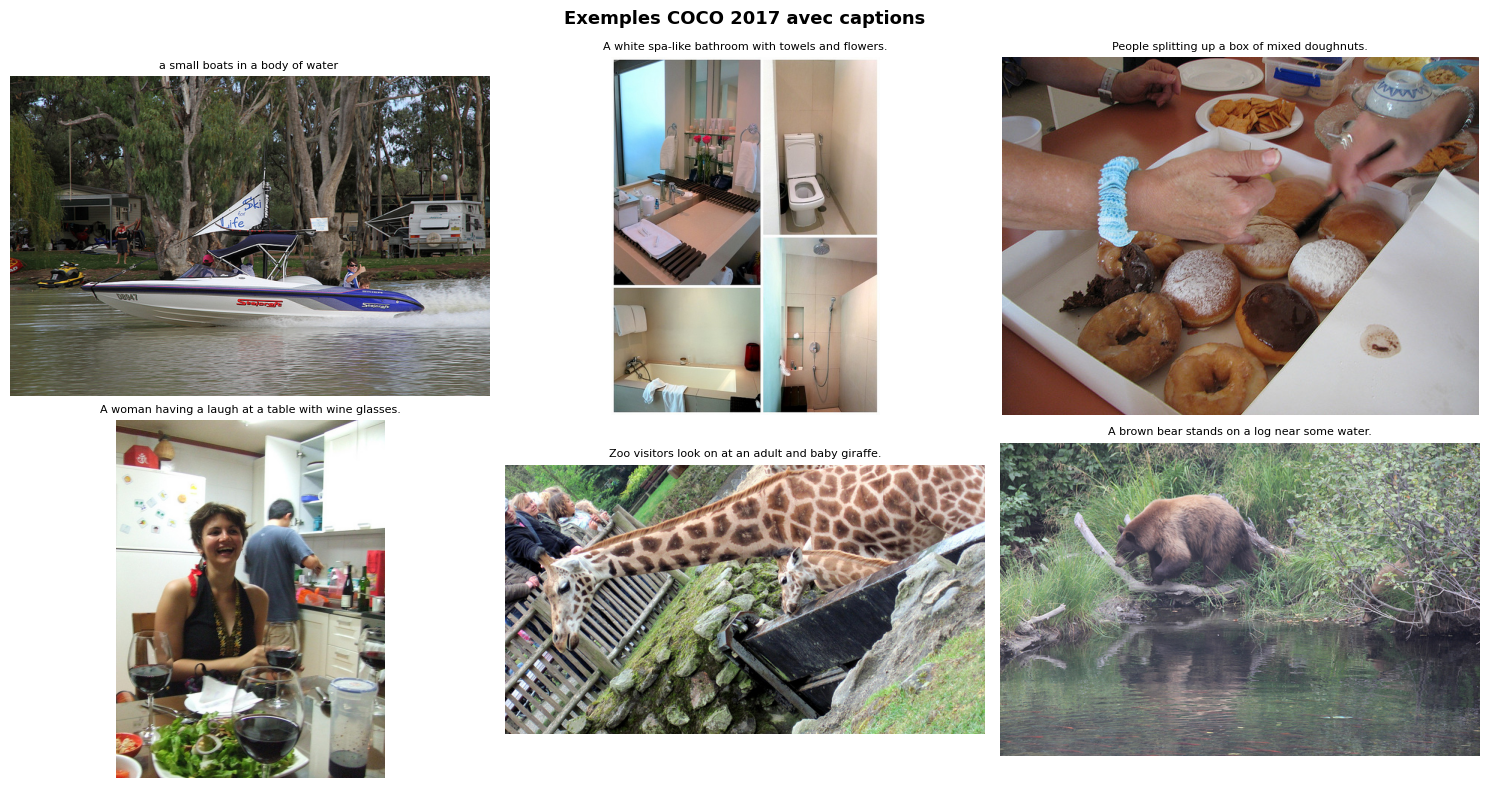

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Exemples COCO 2017 avec captions', fontsize=13, fontweight='bold')
for idx, ax in enumerate(axes.flat):
    img_path = selected_paths[idx]
    try:
        img = Image.open(img_path).convert('RGB')
        cap_clean = image_path_to_caption[img_path][0]
        cap_clean = cap_clean.replace('<start> ','').replace(' <end>','')
        ax.imshow(img)
        ax.set_title(cap_clean[:60], fontsize=8)
    except Exception as e:
        ax.set_title(f'Erreur: {e}', fontsize=8)
    ax.axis('off')
plt.tight_layout(); plt.show()

---
## 2. Pretraitement des Images — InceptionV3

### Strategie : extraction de features prealable

Plutot que de passer chaque image dans InceptionV3 a chaque epoch, on **precalcule**
les features une seule fois et on les sauvegarde sur disque (`.npy`).

```
Image JPEG  ->  InceptionV3 (gele)  ->  (8, 8, 2048)  ->  reshape  ->  (64, 2048)
                                                                           |
                                                               Sauvegarde .npy
```

**Avantage** : l'entrainement lit des tableaux numpy -> 10x plus rapide.

### Pourquoi garder la dimension spatiale (64 = 8x8) ?

En gardant les 64 positions spatiales (au lieu de GlobalAvgPool), l'attention
peut apprendre **quelle region** de l'image regarder pour predire chaque mot.
C'est la cle du mecanisme d'attention de Bahdanau.

In [7]:
# ---- Modele d'extraction InceptionV3 ----
inception = tf.keras.applications.InceptionV3(include_top=False, weights='imagenet')
image_features_extract_model = tf.keras.Model(
    inception.input, inception.layers[-1].output
)  # sortie : (batch, 8, 8, 2048)

def load_image(image_path):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (299, 299))
    img = tf.keras.applications.inception_v3.preprocess_input(img)
    return img, image_path

# ---- Extraction et sauvegarde ----
encode_train = sorted(set(all_img_paths))
to_encode    = [p for p in encode_train if not os.path.exists(p + '.npy')]
print(f'Images a encoder : {len(to_encode)} / {len(encode_train)}')

if to_encode:
    image_dataset = tf.data.Dataset.from_tensor_slices(to_encode)
    image_dataset = image_dataset.map(
        load_image, num_parallel_calls=tf.data.AUTOTUNE).batch(16)
    for img_batch, path_batch in tqdm(image_dataset, desc='InceptionV3'):
        batch_features = image_features_extract_model(img_batch)
        # (16, 8, 8, 2048) -> (16, 64, 2048)
        batch_features = tf.reshape(batch_features,
                                    (batch_features.shape[0], -1, batch_features.shape[3]))
        for feat, path in zip(batch_features, path_batch):
            np.save(path.numpy().decode('utf-8'), feat.numpy())
    print('Extraction terminee.')
else:
    print('Toutes les features sont deja en cache.')

sample_feat = np.load(encode_train[0] + '.npy')
print(f'Shape feature : {sample_feat.shape}  (64 positions x 2048 features)')

2026-06-08 11:03:17.033661: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:09:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-08 11:03:17.033821: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:09:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-08 11:03:17.033866: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:09:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-08 11:03:17.753024: I tensorflow/compiler/xla/stream_executor/cuda/cuda_gpu_executor.cc:880] could not open file to read NUMA node: /sys/bus/pci/devices/0000:09:00.0/numa_node
Your kernel may have been built without NUMA support.
2026-06-08 11:03:17.753129: I tensorflow/compile

Images a encoder : 0 / 118287
Toutes les features sont deja en cache.
Shape feature : (64, 2048)  (64 positions x 2048 features)


---
## 3. Pretraitement du Texte — Tokenisation

```
Caption brute  ->  Tokenizer (top 5 000 mots)  ->  Sequence d entiers  ->  Padding
'<start> A cat sits... <end>'  ->  [1, 4, 312, 87, 2]  ->  [1, 4, 312, 87, 2, 0, 0, ...]
```

| Parametre | Valeur |
|-----------|--------|
| Vocabulaire | 5 000 mots + unk + pad |
| Filtres | Ponctuation supprimee |
| Padding | Post (zeros a droite) |
| Max length | Calculee depuis le corpus |

In [8]:
tokenizer = tf.keras.preprocessing.text.Tokenizer(
    num_words=TOP_K,
    oov_token='<unk>',
    filters='!"#$%&()*+.,-/:;=?@[\\]^_`{|}~ '
)
tokenizer.fit_on_texts(all_captions)
tokenizer.word_index['<pad>'] = 0
tokenizer.index_word[0]       = '<pad>'

train_seqs  = tokenizer.texts_to_sequences(all_captions)
cap_vector  = tf.keras.preprocessing.sequence.pad_sequences(train_seqs, padding='post')
max_length  = max(len(s) for s in train_seqs)
vocab_size  = TOP_K + 1

print(f'Vocabulaire    : {vocab_size} mots')
print(f'Longueur max   : {max_length} tokens')
print(f'Shape cap_vector: {cap_vector.shape}')
print(f'Index <start>  : {tokenizer.word_index.get("<start>", -1)}')
print(f'Index <end>    : {tokenizer.word_index.get("<end>", -1)}')

# Sauvegarde
# Sauvegarder tokenizer ET max_length ensemble
with open(TOKENIZER_PATH, 'wb') as f:
    pickle.dump({'tokenizer': tokenizer, 'max_length': max_length}, f)
print(f'Tokenizer sauvegarde : {TOKENIZER_PATH} (max_length={max_length})')

Vocabulaire    : 7001 mots
Longueur max   : 52 tokens
Shape cap_vector: (591753, 52)
Index <start>  : 3
Index <end>    : 4
Tokenizer sauvegarde : notebooks/tokenizer_coco.pkl (max_length=52)


---
## 4. Split Train / Val / Test et Pipeline tf.data

### Split au niveau des images (80 / 10 / 10)

On sépare les **images** (pas les paires) pour éviter le data leakage.
Toutes les captions d'une même image restent dans le même split.

```
6 000 images  ->  Train : 80% (4 800 images, ~24 000 paires)
              ->  Val   : 10% (  600 images, ~ 3 000 paires)
              ->  Test  : 10% (  600 images, ~ 3 000 paires)
```

### Pipeline lazy

Les features `.npy` sont chargees en lazy a partir du disque,
ce qui evite de tout charger en RAM.

In [9]:
img_to_cap_vector = collections.defaultdict(list)
for img_path, cap_vec in zip(all_img_paths, cap_vector):
    img_to_cap_vector[img_path].append(cap_vec)

img_keys = list(img_to_cap_vector.keys())
random.shuffle(img_keys)

train_end = int(len(img_keys) * 0.80)
val_end   = int(len(img_keys) * 0.90)

keys_train = img_keys[:train_end]
keys_val   = img_keys[train_end:val_end]
keys_test  = img_keys[val_end:]

def build_split(keys):
    img_list, cap_list = [], []
    for k in keys:
        caps = img_to_cap_vector[k]
        img_list.extend([k] * len(caps))
        cap_list.extend(caps)
    return img_list, cap_list

img_name_train, cap_train = build_split(keys_train)
img_name_val,   cap_val   = build_split(keys_val)
img_name_test,  cap_test  = build_split(keys_test)

print(f'Train : {len(img_name_train):>6} paires  ({len(keys_train)} images)')
print(f'Val   : {len(img_name_val):>6} paires  ({len(keys_val)} images)')
print(f'Test  : {len(img_name_test):>6} paires  ({len(keys_test)} images)')
# Sauvegarde du test split pour la reprise sans reentrainement
import pickle as _pkl
with open('notebooks/data_3/test_split.pkl', 'wb') as _f:
    _pkl.dump({'img_name_test': img_name_test, 'cap_test': cap_test}, _f)
print('Test split sauvegarde : notebooks/data_3/test_split.pkl')

Train : 473402 paires  (94629 images)
Val   :  59175 paires  (11829 images)
Test  :  59176 paires  (11829 images)
Test split sauvegarde : notebooks/data_3/test_split.pkl


In [10]:
def map_func(img_name, cap):
    img_tensor = np.load(img_name.decode('utf-8') + '.npy')
    return img_tensor, cap

def make_dataset(img_list, cap_list, shuffle=True):
    ds = tf.data.Dataset.from_tensor_slices((img_list, cap_list))
    ds = ds.map(
        lambda i, c: tf.numpy_function(map_func, [i, c], [tf.float32, tf.int32]),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    if shuffle:
        ds = ds.shuffle(BUFFER_SIZE)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_dataset = make_dataset(img_name_train, cap_train, shuffle=True)
val_dataset   = make_dataset(img_name_val,   cap_val,   shuffle=False)
test_dataset  = make_dataset(img_name_test,  cap_test,  shuffle=False)
num_steps_train = len(img_name_train) // BATCH_SIZE

for feat_batch, cap_batch in train_dataset.take(1):
    print(f'Features : {feat_batch.shape}  (batch, 64 positions, 2048 features)')
    print(f'Captions : {cap_batch.shape}')

Features : (128, 64, 2048)  (batch, 64 positions, 2048 features)
Captions : (128, 52)


---
## 5. Modele CNN Encoder + RNN Decoder (Attention Bahdanau)

### Architecture

```
Features InceptionV3 (batch, 64, 2048)
         |
     CNN Encoder (Dense 2048->256)
         |
     (batch, 64, 256)  <- 64 positions spatiales
         |
     Attention Bahdanau  <-- etat GRU h_{t-1}
         |
     Vecteur de contexte (batch, 256)
         |
     Concat [contexte, embedding(mot_courant)]
         |
     GRU Cell (512 unites)
         |
     Dense(vocab_size) -> logits
```

### Mecanisme d'Attention Bahdanau

Pour predire le t-ieme mot :
1. Score = tanh(W1 x features + W2 x h_{t-1})
2. Poids = softmax(V x score) : distribution sur 64 positions
3. Contexte = somme(poids x features)

Le reseau apprend a **regarder** les bonnes regions selon le mot a predire.

In [11]:
class CNN_Encoder(tf.keras.Model):
    # Projette les features InceptionV3 (64, 2048) -> (64, embedding_dim)
    def __init__(self, embedding_dim):
        super().__init__()
        self.fc = layers.Dense(embedding_dim)

    def call(self, x):
        return tf.nn.relu(self.fc(x))

enc_test = CNN_Encoder(EMBEDDING_DIM)
print(f'CNN Encoder : (batch, 64, 2048) -> {enc_test(tf.zeros((2,64,2048))).shape}')

CNN Encoder : (batch, 64, 2048) -> (2, 64, 512)


In [12]:
class BahdanauAttention(tf.keras.Model):
    # Attention additive : combine features image et etat GRU
    # features : (batch, 64, embedding_dim)
    # hidden   : (batch, units)
    # -> context_vector (batch, embedding_dim) + attention_weights (batch, 64, 1)
    def __init__(self, units):
        super().__init__()
        self.W1 = layers.Dense(units)  # projette les features
        self.W2 = layers.Dense(units)  # projette l etat cache
        self.V  = layers.Dense(1)      # score scalaire par position

    def call(self, features, hidden):
        hidden_exp       = tf.expand_dims(hidden, 1)           # (batch, 1, units)
        score            = self.V(tf.nn.tanh(
            self.W1(features) + self.W2(hidden_exp)))          # (batch, 64, 1)
        attention_weights = tf.nn.softmax(score, axis=1)       # (batch, 64, 1)
        context_vector   = tf.reduce_sum(
            attention_weights * features, axis=1)              # (batch, embed_dim)
        return context_vector, attention_weights

att_test = BahdanauAttention(UNITS)
ctx, attn_w = att_test(tf.zeros((2,64,EMBEDDING_DIM)), tf.zeros((2,UNITS)))
print(f'Contexte : {ctx.shape}  |  Poids attention : {attn_w.shape}')

Contexte : (2, 512)  |  Poids attention : (2, 64, 1)


In [13]:
class RNN_Decoder(tf.keras.Model):
    # Decodeur GRU avec attention de Bahdanau
    # Genere la description mot par mot
    def __init__(self, embedding_dim, units, vocab_size):
        super().__init__()
        self.units     = units
        self.embedding = layers.Embedding(vocab_size, embedding_dim)
        self.gru = layers.GRU(units,
                              return_sequences=True,
                              return_state=True,
                              recurrent_initializer='glorot_uniform')
        self.fc1       = layers.Dense(units)
        self.fc2       = layers.Dense(vocab_size, dtype='float32')
        self.attention = BahdanauAttention(units)

    def call(self, x, features, hidden):
        context_vector, attention_weights = self.attention(features, hidden)
        x = self.embedding(x)                                       # (batch, 1, embed)
        x = tf.concat([tf.expand_dims(context_vector, 1), x], axis=-1)  # (batch, 1, 2*embed)
        output, state = self.gru(x)
        y = self.fc1(tf.reshape(output, (-1, output.shape[2])))
        y = self.fc2(y)                                             # (batch, vocab_size)
        return y, state, attention_weights

    def reset_state(self, batch_size):
        return tf.zeros((batch_size, self.units))

encoder_rnn = CNN_Encoder(EMBEDDING_DIM)
decoder_rnn = RNN_Decoder(EMBEDDING_DIM, UNITS, vocab_size)
print('Modele RNN instancie.')

Modele RNN instancie.


In [14]:
loss_object_rnn = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=True, reduction='none')

def loss_fn_rnn(real, pred):
    mask = tf.cast(tf.math.logical_not(tf.math.equal(real, 0)), tf.float32)
    return tf.reduce_mean(loss_object_rnn(real, pred) * mask)

optimizer_rnn = tf.keras.optimizers.Adam()
ckpt_rnn      = tf.train.Checkpoint(encoder=encoder_rnn, decoder=decoder_rnn,
                                     optimizer=optimizer_rnn)
ckpt_mgr_rnn  = tf.train.CheckpointManager(ckpt_rnn, CHECKPOINT_DIR_RNN, max_to_keep=3)

start_epoch_rnn = 0
if ckpt_mgr_rnn.latest_checkpoint:
    start_epoch_rnn = int(ckpt_mgr_rnn.latest_checkpoint.split('-')[-1])
    ckpt_rnn.restore(ckpt_mgr_rnn.latest_checkpoint)
    print(f'Checkpoint RNN restaure : epoch {start_epoch_rnn}')
else:
    print('Entrainement RNN from scratch.')

Checkpoint RNN restaure : epoch 5


In [15]:
@tf.function
def train_step_rnn(img_tensor, target):
    loss   = 0
    hidden = decoder_rnn.reset_state(batch_size=target.shape[0])
    dec_in = tf.expand_dims(
        [tokenizer.word_index['<start>']] * target.shape[0], 1)

    with tf.GradientTape() as tape:
        features = encoder_rnn(img_tensor)
        for i in range(1, target.shape[1]):
            preds, hidden, _ = decoder_rnn(dec_in, features, hidden)
            loss += loss_fn_rnn(target[:, i], preds)
            dec_in = tf.expand_dims(target[:, i], 1)   # Teacher forcing

    total_loss = loss / int(target.shape[1])
    variables  = encoder_rnn.trainable_variables + decoder_rnn.trainable_variables
    grads      = tape.gradient(loss, variables)
    optimizer_rnn.apply_gradients(zip(grads, variables))
    return loss, total_loss

@tf.function
def val_step_rnn(img_tensor, target):
    loss   = 0
    hidden = decoder_rnn.reset_state(batch_size=target.shape[0])
    dec_in = tf.expand_dims(
        [tokenizer.word_index['<start>']] * target.shape[0], 1)
    features = encoder_rnn(img_tensor)
    for i in range(1, target.shape[1]):
        preds, hidden, _ = decoder_rnn(dec_in, features, hidden)
        loss += loss_fn_rnn(target[:, i], preds)
        dec_in = tf.expand_dims(target[:, i], 1)
    return loss / int(target.shape[1])

print('Fonctions train_step et val_step RNN compilees.')

Fonctions train_step et val_step RNN compilees.


Entrainement CNN+RNN | Epochs: 20 | Batch: 128
-------------------------------------------------------


2026-06-06 09:23:18.905390: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:442] Loaded cuDNN version 8600
2026-06-06 09:23:20.079661: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x7b00682f3490 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-06-06 09:23:20.079722: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 2080, Compute Capability 7.5
2026-06-06 09:23:20.089670: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-06-06 09:23:20.226106: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


  Ep  1 | B    0 | loss 1.9729
  Ep  1 | B  100 | loss 1.0443
  Ep  1 | B  200 | loss 0.9285
  Ep  1 | B  300 | loss 0.8321
  Ep  1 | B  400 | loss 0.7662
  Ep  1 | B  500 | loss 0.7297
  Ep  1 | B  600 | loss 0.6854
  Ep  1 | B  700 | loss 0.7208
  Ep  1 | B  800 | loss 0.7132
  Ep  1 | B  900 | loss 0.6506
  Ep  1 | B 1000 | loss 0.6294
  Ep  1 | B 1100 | loss 0.6942
  Ep  1 | B 1200 | loss 0.6656
  Ep  1 | B 1300 | loss 0.6471
  Ep  1 | B 1400 | loss 0.6685
  Ep  1 | B 1500 | loss 0.6308
  Ep  1 | B 1600 | loss 0.6738
  Ep  1 | B 1700 | loss 0.6069
  Ep  1 | B 1800 | loss 0.6976
  Ep  1 | B 1900 | loss 0.6371
  Ep  1 | B 2000 | loss 0.6065
  Ep  1 | B 2100 | loss 0.6215
  Ep  1 | B 2200 | loss 0.6344
  Ep  1 | B 2300 | loss 0.6281
  Ep  1 | B 2400 | loss 0.5795
  Ep  1 | B 2500 | loss 0.6476
  Ep  1 | B 2600 | loss 0.6332
  Ep  1 | B 2700 | loss 0.6403
  Ep  1 | B 2800 | loss 0.6199
  Ep  1 | B 2900 | loss 0.6562
  Ep  1 | B 3000 | loss 0.6176
  Ep  1 | B 3100 | loss 0.6373
  Ep  1 

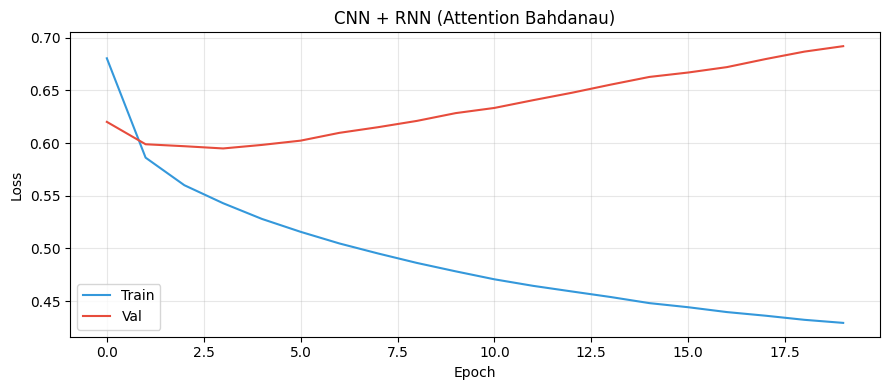

Historique RNN sauvegarde : ./history_rnn.json


In [ ]:
train_losses_rnn, val_losses_rnn = [], []

print(f'Entrainement CNN+RNN | Epochs: {EPOCHS_RNN} | Batch: {BATCH_SIZE}')
print('-' * 55)

for epoch in range(start_epoch_rnn, EPOCHS_RNN):
    t0 = time.time()
    total_train = total_val = 0

    for batch, (img_t, cap_t) in enumerate(train_dataset):
        _, t_loss = train_step_rnn(img_t, cap_t)
        total_train += t_loss
        if batch % 100 == 0:
            print(f'  Ep {epoch+1:2d} | B {batch:4d} | loss {t_loss:.4f}')

    for img_v, cap_v in val_dataset:
        total_val += val_step_rnn(img_v, cap_v)

    n_val_steps = len(img_name_val) // BATCH_SIZE + 1
    avg_tr = float(total_train / num_steps_train)
    avg_vl = float(total_val   / n_val_steps)
    train_losses_rnn.append(avg_tr)
    val_losses_rnn.append(avg_vl)

    if (epoch + 1) % 5 == 0:
        ckpt_mgr_rnn.save()
    print(f'Epoch {epoch+1:2d}/{EPOCHS_RNN} | '
          f'Train: {avg_tr:.4f} | Val: {avg_vl:.4f} | {time.time()-t0:.0f}s')

ckpt_mgr_rnn.save()

### Affichage des courbes d'apprentissage

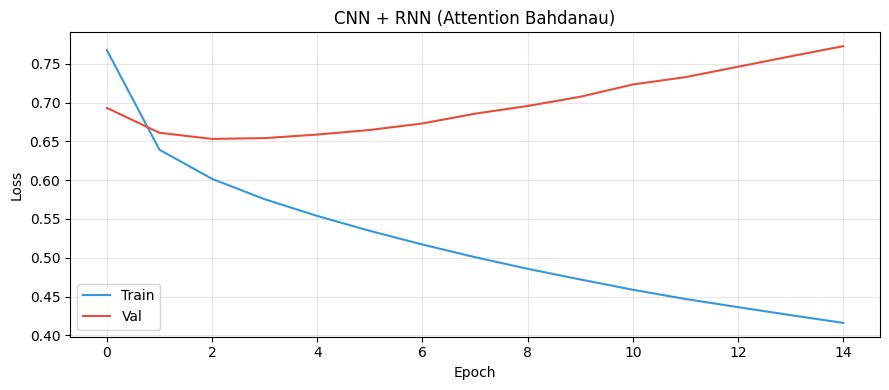

In [24]:
import json as _json
with open('notebooks/history_rnn.json') as f:
    _h_rnn = _json.load(f)
train_losses_rnn = _h_rnn['train']
val_losses_rnn   = _h_rnn['val']

plt.figure(figsize=(9,4))
plt.plot(train_losses_rnn, label='Train', color='#3498db')
plt.plot(val_losses_rnn,   label='Val',   color='#e74c3c')
plt.xlabel('Epoch'); plt.ylabel('Loss')
plt.title('CNN + RNN (Attention Bahdanau)')
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

### Sauvegarde de l'entrainement du modèle

In [25]:
# Sauvegarde de l historique pour la reprise
with open('./history_rnn.json', 'w') as _f:
    json.dump({'train': train_losses_rnn, 'val': val_losses_rnn}, _f)
print('Historique RNN sauvegarde : ./history_rnn.json')

Historique RNN sauvegarde : ./history_rnn.json


### Fonctions d'évaluation des RNN

In [16]:
def evaluate_rnn(image_path):
    # Genere un caption + les poids d attention pour chaque mot
    attention_plot = np.zeros((max_length, 64))
    hidden  = decoder_rnn.reset_state(batch_size=1)
    img, _  = load_image(image_path)
    feat    = image_features_extract_model(tf.expand_dims(img, 0))
    feat    = tf.reshape(feat, (feat.shape[0], -1, feat.shape[3]))
    feat    = encoder_rnn(feat)
    dec_in  = tf.expand_dims([tokenizer.word_index['<start>']], 0)
    result  = []
    for i in range(max_length):
        preds, hidden, attn_w = decoder_rnn(dec_in, feat, hidden)
        attention_plot[i]     = tf.reshape(attn_w, (-1,)).numpy()
        pred_id = tf.argmax(preds[0]).numpy()
        word    = tokenizer.index_word.get(pred_id, '<unk>')
        if word == '<end>':
            break
        result.append(word)
        dec_in = tf.expand_dims([pred_id], 0)
    return ' '.join(result), attention_plot[:len(result)]

def evaluate_rnn_beam(image_path, beam_size=BEAM_SIZE):
    # Beam search pour le decodeur RNN
    img, _  = load_image(image_path)
    feat    = image_features_extract_model(tf.expand_dims(img, 0))
    feat    = tf.reshape(feat, (feat.shape[0], -1, feat.shape[3]))
    feat    = encoder_rnn(feat)
    start_id = tokenizer.word_index['<start>']
    end_id   = tokenizer.word_index.get('<end>', 2)
    h0     = decoder_rnn.reset_state(batch_size=1)
    beams  = [(0.0, [start_id], h0)]
    done   = []
    for _ in range(max_length):
        all_next = []
        for score, toks, h in beams:
            if toks[-1] == end_id:
                done.append((score, toks)); continue
            dec_in    = tf.expand_dims([toks[-1]], 0)
            preds, h_new, _ = decoder_rnn(dec_in, feat, h)
            log_p     = tf.nn.log_softmax(preds[0]).numpy()
            top_ids   = np.argsort(log_p)[-beam_size:]
            for tid in top_ids:
                all_next.append((score + log_p[tid], toks + [int(tid)], h_new))
        if not all_next:
            break
        beams = sorted(all_next, key=lambda x: -x[0])[:beam_size]
        if len(done) >= beam_size:
            break
    done += [(s, t) for s, t, _ in beams]
    best  = sorted(done, key=lambda x: -x[0] / max(len(x[1]), 1))[0][1]
    words = [tokenizer.index_word.get(t, '') for t in best[1:] if t not in (end_id, start_id)]
    return ' '.join(w for w in words if w)

=== Evaluation qualitative — CNN + RNN ===



2026-06-08 08:59:42.110772: I tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:442] Loaded cuDNN version 8600


Reel  : <start> a wall mount clock with a wall street sign on the front of a building <end>
Predit: a large clock on a building



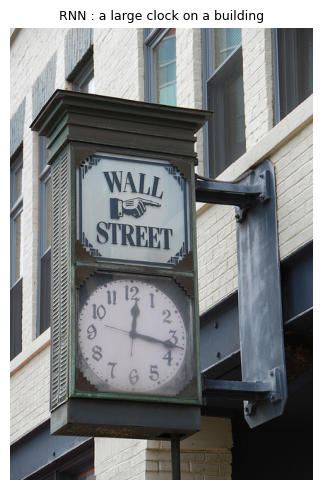

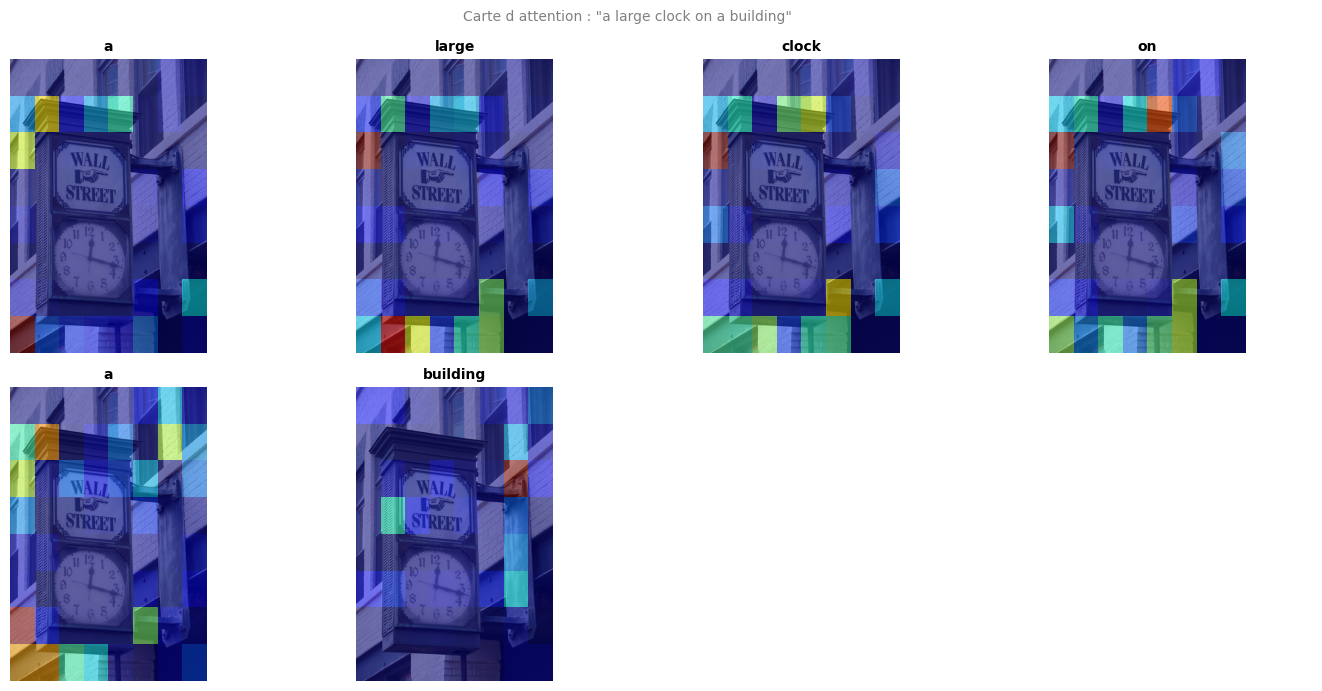

Reel  : <start> a giraffe standing on a path looking over a field <end>
Predit: a giraffe standing in the sand



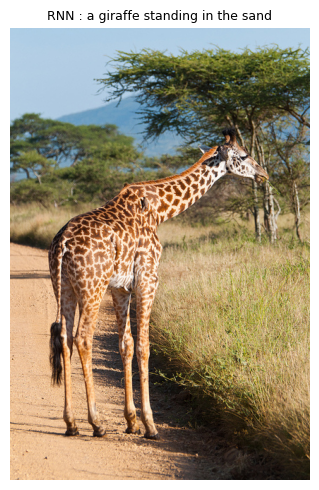

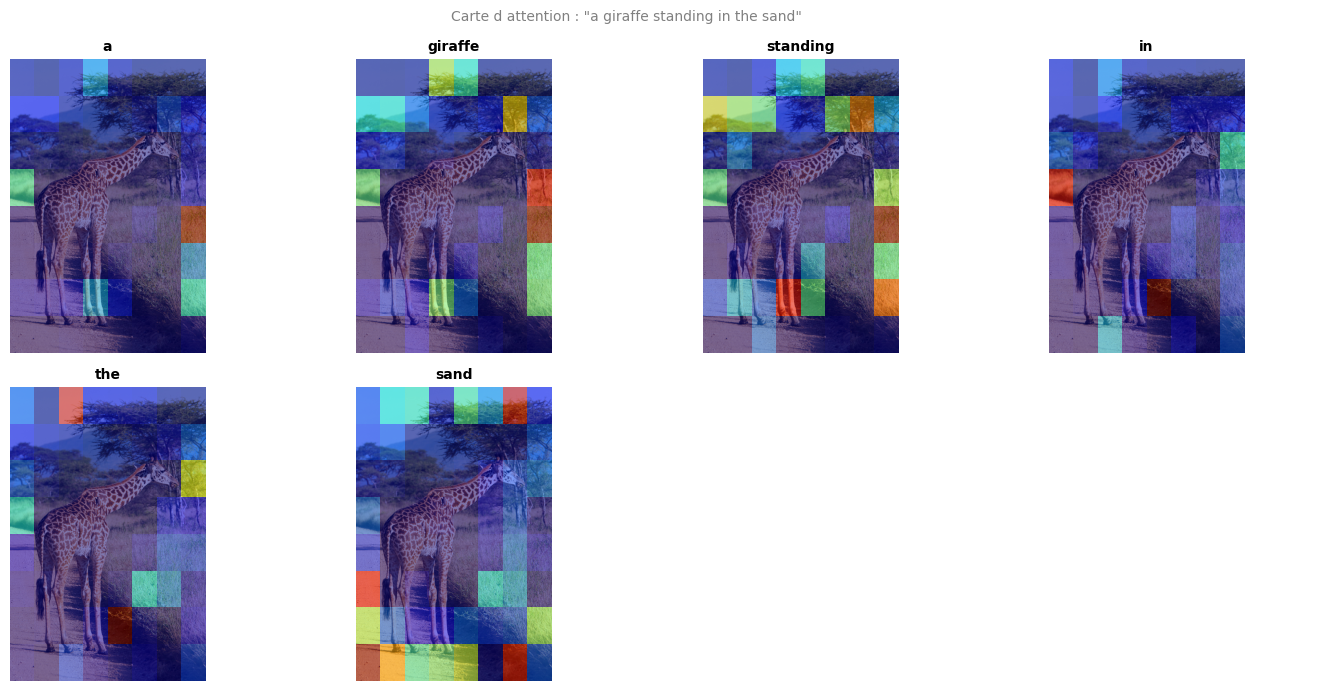

Reel  : <start> a large jetliner sitting on top of a runway <end>
Predit: a large passenger jet sitting on top of an airport runway



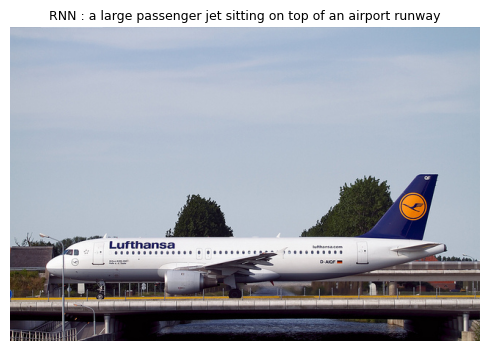

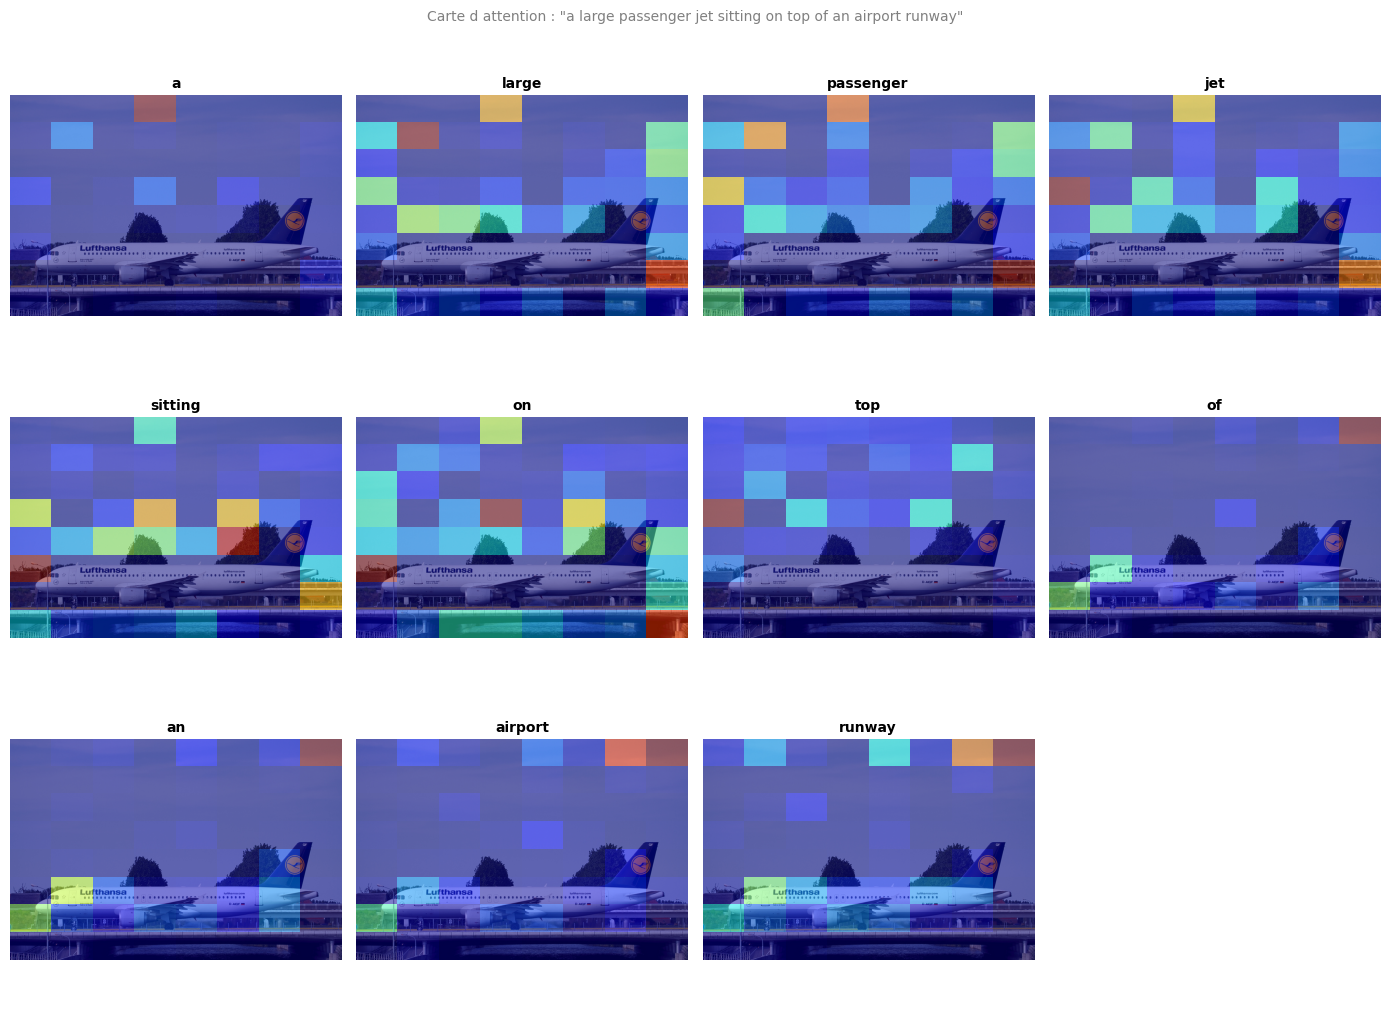

In [ ]:
def plot_attention_map(image_path, caption, attn_weights):
    img   = np.array(Image.open(image_path))
    words = caption.split()
    n     = min(len(words), 12)
    cols  = 4
    rows  = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 3.5))
    for idx, ax in enumerate(axes.flat):
        if idx < n:
            att = np.resize(attn_weights[idx], (8, 8))
            im  = ax.imshow(img)
            ax.imshow(att, cmap='jet', alpha=0.5, extent=im.get_extent())
            ax.set_title(words[idx], fontsize=10, fontweight='bold')
        ax.axis('off')
    plt.suptitle(f'Carte d attention : "{caption}"', fontsize=10, color='gray')
    plt.tight_layout(); plt.show()

# Evaluation qualitative
print('=== Evaluation qualitative — CNN + RNN ===\n')
for i in range(3):
    idx   = i * (len(img_name_test) // 3)
    img_p = img_name_test[idx]
    real  = ' '.join([tokenizer.index_word.get(int(t),'') for t in cap_test[idx] if t != 0])
    pred, attn = evaluate_rnn(img_p)
    print(f'Reel  : {real}')
    print(f'Predit: {pred}\n')
    fig, ax = plt.subplots(figsize=(5,5))
    ax.imshow(Image.open(img_p)); ax.axis('off')
    ax.set_title(f'RNN : {pred[:60]}', fontsize=9)
    plt.tight_layout(); plt.show()
    plot_attention_map(img_p, pred, attn)

---
## 6. Modele CNN Encoder + Transformer Decoder

### Pourquoi un Transformer ?

| Critere | RNN (GRU) | Transformer |
|---------|-----------|-------------|
| **Memoire** | Etat cache (court terme) | Attention globale sur la sequence |
| **Parallelisme** | Sequentiel | Parallele |
| **Dependances longues** | Vanishing gradient | Direct via attention |
| **Performance** | Bon | Meilleur |

### Architecture Decoder

```
Caption tokens -> Embedding + Positional Encoding
                      |
              Decoder Block x N
              +-----------------------------+
              | Masked Self-Attention       |  <- ne voit pas le futur
              | Add & LayerNorm             |
              | Cross-Attention (CNN feats) |  <- regarde l image
              | Add & LayerNorm             |
              | Feed-Forward                |
              | Add & LayerNorm             |
              +-----------------------------+
                      |
               Dense(vocab_size)
```

In [17]:
def get_positional_encoding(max_len, d_model):
    positions = np.arange(max_len)[:, np.newaxis]
    dims      = np.arange(d_model)[np.newaxis, :]
    angles    = positions / np.power(10000, (2*(dims//2)) / np.float32(d_model))
    angles[:, 0::2] = np.sin(angles[:, 0::2])
    angles[:, 1::2] = np.cos(angles[:, 1::2])
    return tf.cast(angles[np.newaxis, :, :], tf.float32)

class DecoderBlock(layers.Layer):
    def __init__(self, embed_dim, num_heads, ff_dim, dropout=0.3):
        super().__init__()
        kd = embed_dim // num_heads
        self.self_attn  = layers.MultiHeadAttention(num_heads=num_heads, key_dim=kd,
                                                    dropout=dropout)
        self.cross_attn = layers.MultiHeadAttention(num_heads=num_heads, key_dim=kd,
                                                    dropout=dropout)
        self.ffn  = tf.keras.Sequential([
            layers.Dense(ff_dim, activation='relu'),
            layers.Dropout(dropout),
            layers.Dense(embed_dim),
        ])
        self.norm1 = layers.LayerNormalization(epsilon=1e-6)
        self.norm2 = layers.LayerNormalization(epsilon=1e-6)
        self.norm3 = layers.LayerNormalization(epsilon=1e-6)
        self.drop  = layers.Dropout(dropout)

    def call(self, x, enc_output, training=False):
        x = self.norm1(x + self.drop(
            self.self_attn(x, x, x, use_causal_mask=True, training=training),
            training=training))
        x = self.norm2(x + self.drop(
            self.cross_attn(x, enc_output, enc_output, training=training),
            training=training))
        x = self.norm3(x + self.drop(self.ffn(x, training=training), training=training))
        return x

class TransformerCaptioner(tf.keras.Model):
    def __init__(self, vocab_size, embed_dim, num_heads, ff_dim,
                 num_layers, max_len, dropout=0.3):
        super().__init__()
        self.embedding  = layers.Embedding(vocab_size, embed_dim)
        self.pos_enc    = get_positional_encoding(max_len + 10, embed_dim)
        self.dec_blocks = [DecoderBlock(embed_dim, num_heads, ff_dim, dropout)
                           for _ in range(num_layers)]
        self.fc_out     = layers.Dense(vocab_size, dtype='float32')
        self.embed_dim  = embed_dim
        self.drop_emb   = layers.Dropout(dropout)

    def call(self, tokens, enc_output, training=False):
        seq_len = tf.shape(tokens)[1]
        x = self.embedding(tokens)
        x = x * tf.math.sqrt(tf.cast(self.embed_dim, dtype=x.dtype))
        pos = tf.cast(self.pos_enc[:, :seq_len, :], dtype=x.dtype)
        x = self.drop_emb(x + pos, training=training)
        for block in self.dec_blocks:
            x = block(x, enc_output, training=training)
        return self.fc_out(x)

encoder_tr = CNN_Encoder(EMBEDDING_DIM)
decoder_tr = TransformerCaptioner(
    vocab_size=vocab_size, embed_dim=EMBEDDING_DIM,
    num_heads=NUM_HEADS, ff_dim=FF_DIM,
    num_layers=NUM_LAYERS_TR, max_len=max_length,
    dropout=DROPOUT_TR,
)
dummy_enc = encoder_tr(tf.zeros((2, 64, 2048)))
dummy_out = decoder_tr(tf.zeros((2, 10), dtype=tf.int32), dummy_enc)
print(f'Encoder output : {dummy_enc.shape}')
print(f'Decoder output : {dummy_out.shape}  (batch, seq, vocab)')

Encoder output : (2, 64, 512)
Decoder output : (2, 10, 7001)  (batch, seq, vocab)


In [18]:
# ---- Schedule LR avec warmup (formule Attention is All You Need) ----
class WarmupSchedule(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, d_model, warmup_steps):
        super().__init__()
        self.d_model      = tf.cast(d_model, tf.float32)
        self.warmup_steps = tf.cast(warmup_steps, tf.float32)

    def __call__(self, step):
        step  = tf.cast(step + 1, tf.float32)
        return tf.math.rsqrt(self.d_model) * tf.math.minimum(
            tf.math.rsqrt(step),
            step * tf.math.pow(self.warmup_steps, -1.5)
        )

    def get_config(self):
        return {'d_model': int(self.d_model.numpy()),
                'warmup_steps': int(self.warmup_steps.numpy())}

# ---- Loss avec label smoothing ----
def loss_fn_tr(real, pred, epsilon=LABEL_SMOOTHING):
    vocab_sz = tf.shape(pred)[-1]
    one_hot  = tf.one_hot(real, vocab_sz, dtype=tf.float32)
    smooth   = one_hot * (1.0 - epsilon) + (epsilon / tf.cast(vocab_sz, tf.float32))
    loss     = tf.nn.softmax_cross_entropy_with_logits(labels=smooth, logits=pred)
    mask     = tf.cast(tf.math.logical_not(tf.math.equal(real, 0)), tf.float32)
    return tf.reduce_sum(loss * mask) / tf.reduce_sum(mask)

lr_schedule  = WarmupSchedule(EMBEDDING_DIM, WARMUP_STEPS)
optimizer_tr = tf.keras.optimizers.AdamW(
    learning_rate=lr_schedule,
    weight_decay=WEIGHT_DECAY,
    beta_1=0.9, beta_2=0.98, epsilon=1e-9
)

ckpt_tr     = tf.train.Checkpoint(encoder=encoder_tr, decoder=decoder_tr,
                                   optimizer=optimizer_tr)
ckpt_mgr_tr = tf.train.CheckpointManager(ckpt_tr, CHECKPOINT_DIR_TR, max_to_keep=3)

@tf.function
def train_step_tr(img_tensor, target):
    dec_in  = target[:, :-1]
    dec_out = target[:, 1:]
    with tf.GradientTape() as tape:
        enc_out = encoder_tr(img_tensor, training=True)
        logits  = decoder_tr(dec_in, enc_out, training=True)
        loss    = loss_fn_tr(dec_out, logits)
    variables = encoder_tr.trainable_variables + decoder_tr.trainable_variables
    grads     = tape.gradient(loss, variables)
    grads, _  = tf.clip_by_global_norm(grads, GRAD_CLIP)
    optimizer_tr.apply_gradients(zip(grads, variables))
    return loss

@tf.function
def val_step_tr(img_tensor, target):
    dec_in, dec_out = target[:, :-1], target[:, 1:]
    enc_out = encoder_tr(img_tensor, training=False)
    logits  = decoder_tr(dec_in, enc_out, training=False)
    return loss_fn_tr(dec_out, logits)

# Récupération du last checkpoint pour la reprise
start_epoch_tr = 0
if ckpt_mgr_tr.latest_checkpoint:
    start_epoch_tr = int(ckpt_mgr_tr.latest_checkpoint.split('-')[-1])
    ckpt_tr.restore(ckpt_mgr_tr.latest_checkpoint)
    print(f'Checkpoint Transformer restaure : epoch {start_epoch_tr}')
else:
    print('Entrainement Transformer from scratch.')

Checkpoint Transformer restaure : epoch 7


In [ ]:
train_losses_tr, val_losses_tr = [], []
start_epoch_tr = 0
if ckpt_mgr_tr.latest_checkpoint:
    start_epoch_tr = int(ckpt_mgr_tr.latest_checkpoint.split('-')[-1])
    ckpt_tr.restore(ckpt_mgr_tr.latest_checkpoint)

print(f'Entrainement CNN+Transformer optimise')
print(f'  LR schedule : warmup {WARMUP_STEPS} steps')
print(f'  Label smooth: {LABEL_SMOOTHING}')
print(f'  Grad clip   : {GRAD_CLIP}')
print(f'  Dropout     : {DROPOUT_TR}')
print(f'  Batch size  : {BATCH_SIZE}')
print(f'  Blocs       : {NUM_LAYERS_TR}  |  FFN dim : {FF_DIM}')
print('-' * 55)

best_val_loss  = float('inf')
patience_count = 0

# Restaurer le meilleur checkpoint -> quitter le programme sans reentrainer
if ckpt_mgr_tr.checkpoints:
    ckpt_tr.restore(ckpt_mgr_tr.latest_checkpoint).expect_partial()
    print(f'Meilleur checkpoint restaure : {ckpt_mgr_tr.latest_checkpoint}')
    exit()

for epoch in range(start_epoch_tr, EPOCHS_TR):
    t0 = time.time()

    total_tr = 0
    for batch, (img_t, cap_t) in enumerate(train_dataset):
        loss_batch = train_step_tr(img_t, cap_t)
        total_tr += loss_batch
        if batch % 100 == 0:
            print(f'  Ep {epoch+1:2d} | B {batch:4d} | loss {loss_batch:.4f}')

    total_vl = 0
    for img_v, cap_v in val_dataset:
        total_vl += val_step_tr(img_v, cap_v)

    n_vl   = len(img_name_val) // BATCH_SIZE + 1
    avg_tr = float(total_tr / num_steps_train)
    avg_vl = float(total_vl / n_vl)
    train_losses_tr.append(avg_tr)
    val_losses_tr.append(avg_vl)

    if avg_vl < best_val_loss:
        best_val_loss  = avg_vl
        patience_count = 0
        ckpt_mgr_tr.save()
        flag = '  << best'
    else:
        patience_count += 1
        flag = f'  (patience {patience_count}/{PATIENCE})'

    current_lr = float(lr_schedule(optimizer_tr.iterations))
    print(f'Epoch {epoch+1:2d}/{EPOCHS_TR} | '
          f'Train: {avg_tr:.4f} | Val: {avg_vl:.4f} | '
          f'LR: {current_lr:.2e} | {time.time()-t0:.0f}s{flag}')

    if patience_count >= PATIENCE:
        print(f'Early stopping a l epoch {epoch+1}.')
        break

print(f'Meilleure val loss : {best_val_loss:.4f}')

### Courbes d'apprentissage

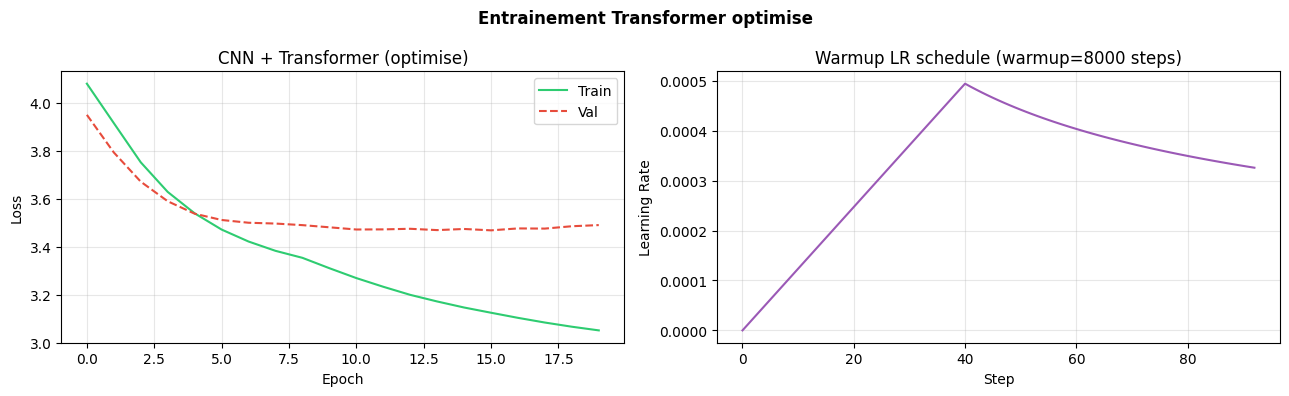

In [25]:
import json as _json
with open('notebooks/history_tr.json') as f:
    _h_tr = _json.load(f)
train_losses_tr = _h_tr['train']
val_losses_tr   = _h_tr['val']

# Courbes
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.plot(train_losses_tr, label='Train', color='#2ecc71')
ax1.plot(val_losses_tr,   label='Val',   color='#e74c3c', linestyle='--')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
ax1.set_title('CNN + Transformer (optimise)')
ax1.legend(); ax1.grid(alpha=0.3)

_lr_fn = WarmupSchedule(EMBEDDING_DIM, WARMUP_STEPS)
n_steps_approx = len(train_losses_tr) * (118287 // BATCH_SIZE)
lrs = [_lr_fn(s).numpy() for s in range(1, n_steps_approx, 200)]
ax2.plot(lrs, color='#9b59b6')
ax2.set_xlabel('Step'); ax2.set_ylabel('Learning Rate')
ax2.set_title(f'Warmup LR schedule (warmup={WARMUP_STEPS} steps)')
ax2.grid(alpha=0.3)
plt.suptitle('Entrainement Transformer optimise', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.show()



### Sauvegarde historique

In [ ]:
# Sauvegarde de l historique pour la reprise
with open('./history_tr.json', 'w') as _f:
    json.dump({'train': train_losses_tr, 'val': val_losses_tr}, _f)
print('Historique Transformer sauvegarde : ./history_tr.json')

Historique Transformer sauvegarde : ./history_tr.json


### Fonctions d'évaluation du transformer

In [19]:
def _get_enc_output(image_path):
    img, _  = load_image(image_path)
    feat    = image_features_extract_model(tf.expand_dims(img, 0))
    feat    = tf.reshape(feat, (feat.shape[0], -1, feat.shape[3]))
    return encoder_tr(feat, training=False)

def evaluate_transformer(image_path):
    # Decodage greedy (argmax a chaque pas)
    enc_out  = _get_enc_output(image_path)
    start_id = tokenizer.word_index['<start>']
    end_id   = tokenizer.word_index.get('<end>', 2)
    tokens   = tf.expand_dims([start_id], 0)
    result   = []
    for _ in range(max_length):
        logits = decoder_tr(tokens, enc_out, training=False)
        pred   = tf.cast(tf.argmax(logits[:, -1, :], axis=-1), tf.int32)
        word   = tokenizer.index_word.get(int(pred[0]), '<unk>')
        if word == '<end>': break
        result.append(word)
        tokens = tf.concat([tokens, tf.expand_dims(pred, 0)], axis=1)
    return ' '.join(result)

def evaluate_transformer_beam(image_path, beam_size=BEAM_SIZE):
    # Beam search : garde les beam_size meilleures hypotheses a chaque pas
    enc_out  = _get_enc_output(image_path)
    start_id = tokenizer.word_index['<start>']
    end_id   = tokenizer.word_index.get('<end>', 2)

    # (log-prob cumulee, sequence de tokens, termine?)
    beams     = [(0.0, [start_id], False)]
    completed = []

    for step in range(max_length):
        new_beams = []
        for log_prob, seq, done in beams:
            if done:
                completed.append((log_prob / len(seq), seq))
                continue
            tokens = tf.expand_dims(seq, 0)
            logits = decoder_tr(tokens, enc_out, training=False)  # (1, len, vocab)
            lp     = tf.nn.log_softmax(logits[0, -1, :]).numpy()  # (vocab,)
            # Longueur normalisee : evite de favoriser les phrases courtes
            length_penalty = ((5 + step + 1) ** 0.6) / ((5 + 1) ** 0.6)
            top_ids = np.argsort(lp)[-beam_size:]
            for tok in top_ids:
                word     = tokenizer.index_word.get(int(tok), '<unk>')
                new_lp   = log_prob + lp[tok]
                new_seq  = seq + [int(tok)]
                new_done = (word == '<end>')
                new_beams.append((new_lp / length_penalty, new_seq, new_done))
        # Trie par score et garde les beam_size meilleurs
        new_beams.sort(key=lambda x: x[0], reverse=True)
        beams = new_beams[:beam_size]
        if all(done for _, _, done in beams):
            break

    for lp, seq, _ in beams:
        completed.append((lp, seq))
    completed.sort(key=lambda x: x[0], reverse=True)

    best_seq = completed[0][1]
    words = [tokenizer.index_word.get(t, '')
             for t in best_seq if t not in (start_id, end_id, 0)]
    return ' '.join(w for w in words if w)

=== Evaluation qualitative — Greedy vs Beam Search ===

Reel   : <start> a wall mount clock with a wall street sign on the front of a building <end>
Greedy : a clock on a building with a sign on it
Beam-5 : a clock on the side of a building with a statue of a man on top of the roof of the clock tower and a building in the background and a building in the background and a window with a blue sky with a blue sky behind it



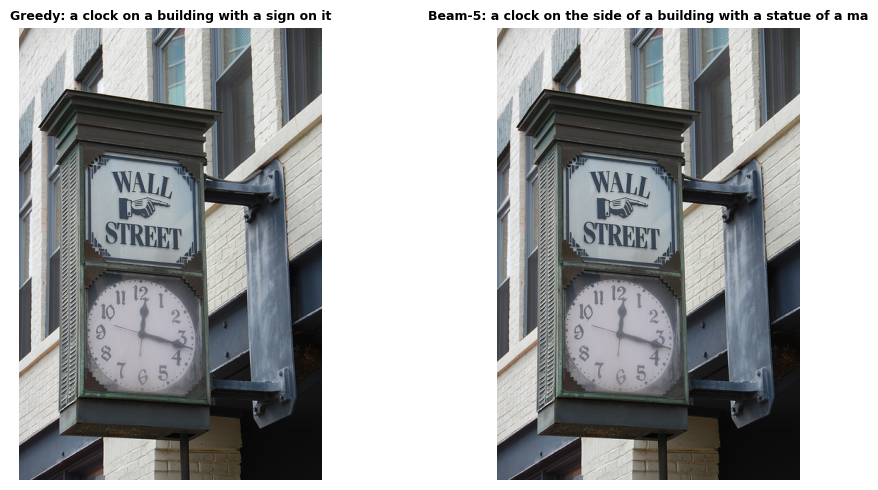

Reel   : <start> a giraffe standing on a path looking over a field <end>
Greedy : a giraffe standing in a field of dirt
Beam-5 : a giraffe standing in the middle of a dirt road in front of a tree and grass covered field with trees in the background of the background and a field with a bird on top of it's head of its head of it's head of it's mouth



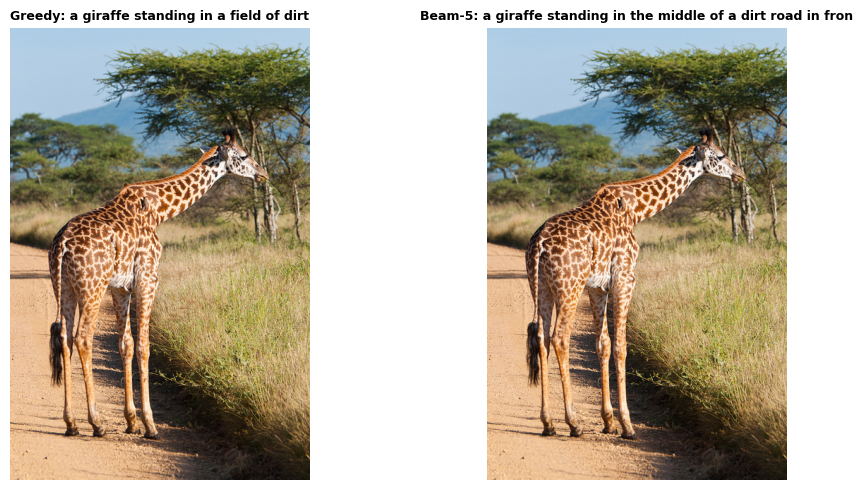

Reel   : <start> a large jetliner sitting on top of a runway <end>
Greedy : a large jet airplane sitting on top of an airport runway
Beam-5 : a large passenger jet sitting on top of an airport runway with it's landing gear down and a sky background of blue sky in the foreground with a sky behind it and blue sky in the background of the plane that has a blue sky behind it



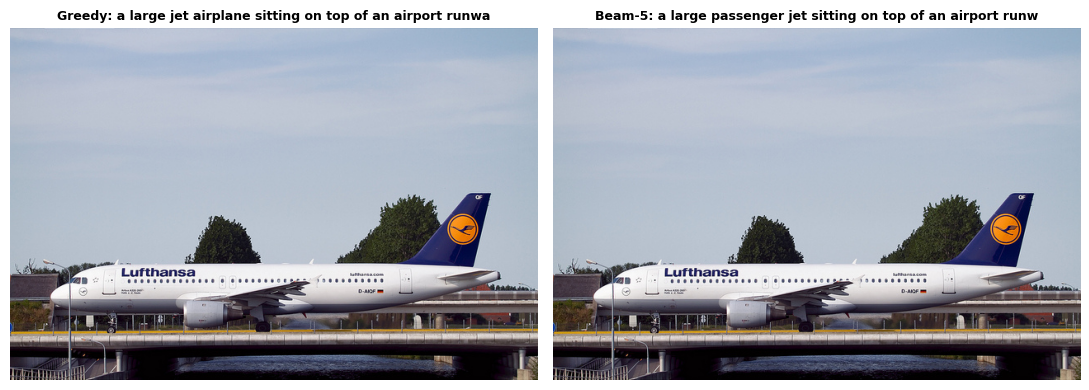

In [ ]:
# ============================================================
# INFERENCE — Greedy + Beam Search
# ============================================================

# ---- Comparaison greedy vs beam search ----
print('=== Evaluation qualitative — Greedy vs Beam Search ===\n')
for i in range(3):
    idx   = i * (len(img_name_test) // 3)
    img_p = img_name_test[idx]
    real  = ' '.join([tokenizer.index_word.get(int(t),'') for t in cap_test[idx] if t != 0])
    greedy = evaluate_transformer(img_p)
    beam   = evaluate_transformer_beam(img_p)
    print(f'Reel   : {real}')
    print(f'Greedy : {greedy}')
    print(f'Beam-{BEAM_SIZE} : {beam}\n')
    fig, axes = plt.subplots(1, 2, figsize=(11, 5))
    for ax, (title, cap) in zip(axes, [
        ('Greedy', greedy), (f'Beam-{BEAM_SIZE}', beam)
    ]):
        ax.imshow(Image.open(img_p)); ax.axis('off')
        ax.set_title(f'{title}: {cap[:55]}', fontsize=9, fontweight='bold')
    plt.tight_layout(); plt.show()

---
## 7. Comparaison des Modeles

### Score BLEU

**BLEU** mesure le chevauchement de n-grammes entre descriptions generees et references humaines.

```
Reference : 'Un chat assis sur un canape rouge'
Generee   : 'Un chat sur un canape'
BLEU-1 : 5/5 = 1.00  |  BLEU-4 : standard en captioning
```

Un score BLEU eleve ne garantit pas la qualite narrative,
mais permet une comparaison objective entre modeles.

### Courbes d'apprentissage

Comparaison des courbes de loss train/val pour les deux modeles entraines.

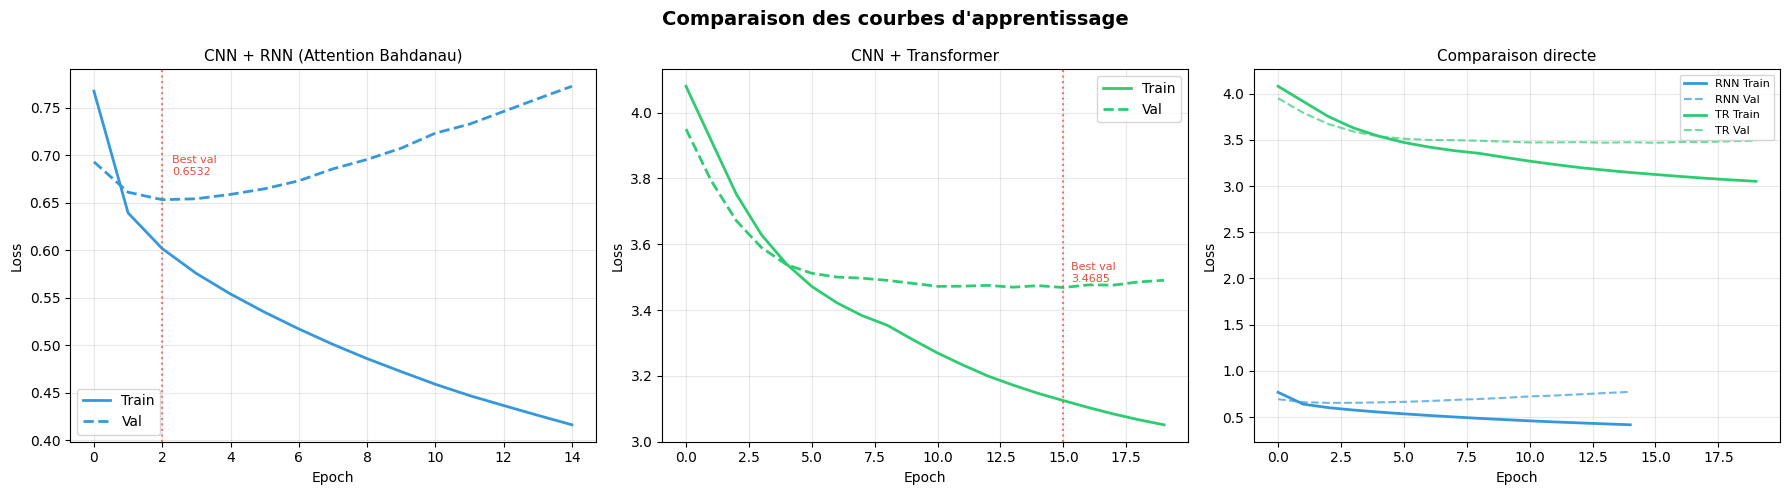

Modele                         Epochs  Best val loss
------------------------------------------------------------
CNN + RNN                          15         0.6532
CNN + Transformer                  20         3.4685
Note : losses non comparables directement (label smoothing sur TR)


In [ ]:
import json as _json

# Chargement depuis les fichiers JSON (independant du kernel)
with open('notebooks/history_rnn.json') as f:
    _h_rnn = _json.load(f)
with open('notebooks/history_tr.json') as f:
    _h_tr  = _json.load(f)

train_losses_rnn = _h_rnn['train']
val_losses_rnn   = _h_rnn['val']
train_losses_tr  = _h_tr['train']
val_losses_tr    = _h_tr['val']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Comparaison des courbes d\'apprentissage', fontsize=14, fontweight='bold')

# ---- Courbe RNN ----
axes[0].plot(train_losses_rnn, label='Train', color='#3498db', linewidth=2)
axes[0].plot(val_losses_rnn,   label='Val',   color='#3498db', linestyle='--', linewidth=2)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('CNN + RNN (Attention Bahdanau)', fontsize=11)
axes[0].legend(); axes[0].grid(alpha=0.3)
best_rnn = min(val_losses_rnn)
ep_rnn   = val_losses_rnn.index(best_rnn)
axes[0].axvline(ep_rnn, color='#e74c3c', linestyle=':', alpha=0.7)
axes[0].annotate(f'Best val\n{best_rnn:.4f}',
                 xy=(ep_rnn, best_rnn), xytext=(ep_rnn + 0.3, best_rnn * 1.04),
                 fontsize=8, color='#e74c3c')

# ---- Courbe Transformer ----
axes[1].plot(train_losses_tr, label='Train', color='#2ecc71', linewidth=2)
axes[1].plot(val_losses_tr,   label='Val',   color='#2ecc71', linestyle='--', linewidth=2)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss')
axes[1].set_title('CNN + Transformer', fontsize=11)
axes[1].legend(); axes[1].grid(alpha=0.3)
best_tr = min(val_losses_tr)
ep_tr   = val_losses_tr.index(best_tr)
axes[1].axvline(ep_tr, color='#e74c3c', linestyle=':', alpha=0.7)
axes[1].annotate(f'Best val\n{best_tr:.4f}',
                 xy=(ep_tr, best_tr), xytext=(ep_tr + 0.3, best_tr * 1.005),
                 fontsize=8, color='#e74c3c')

# ---- Courbes superposees ----
axes[2].plot(train_losses_rnn, label='RNN Train',  color='#3498db', linewidth=2)
axes[2].plot(val_losses_rnn,   label='RNN Val',    color='#3498db', linestyle='--', linewidth=1.5, alpha=0.7)
axes[2].plot(train_losses_tr,  label='TR Train',   color='#2ecc71', linewidth=2)
axes[2].plot(val_losses_tr,    label='TR Val',     color='#2ecc71', linestyle='--', linewidth=1.5, alpha=0.7)
axes[2].set_xlabel('Epoch'); axes[2].set_ylabel('Loss')
axes[2].set_title('Comparaison directe', fontsize=11)
axes[2].legend(fontsize=8); axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()

# ---- Tableau recap ----
print('=' * 60)
print(f'{"Modele":<30} {"Epochs":>6} {"Best val loss":>14}')
print('-' * 60)
print(f'{"CNN + RNN":<30} {len(train_losses_rnn):>6} {best_rnn:>14.4f}')
print(f'{"CNN + Transformer":<30} {len(train_losses_tr):>6} {best_tr:>14.4f}')
print('=' * 60)
print('Note : losses non comparables directement (label smoothing sur TR)')

### Évaluation BLEU

Evaluation BLEU 118K (multi-references, N=200)

CNN + RNN (greedy)                             BLEU-1: 37.87%  |  BLEU-4: 9.15%
CNN + Transformer (greedy)                     BLEU-1: 47.67%  |  BLEU-4: 13.74%

  Modele                                         BLEU-1   BLEU-4
  CNN + RNN (greedy)                             37.87%    9.15%
  CNN + Transformer (greedy)                     47.67%   13.74%


/tmp/ipykernel_23862/2049813551.py:65: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(_names, rotation=28, ha='right', fontsize=9)
/tmp/ipykernel_23862/2049813551.py:65: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(_names, rotation=28, ha='right', fontsize=9)


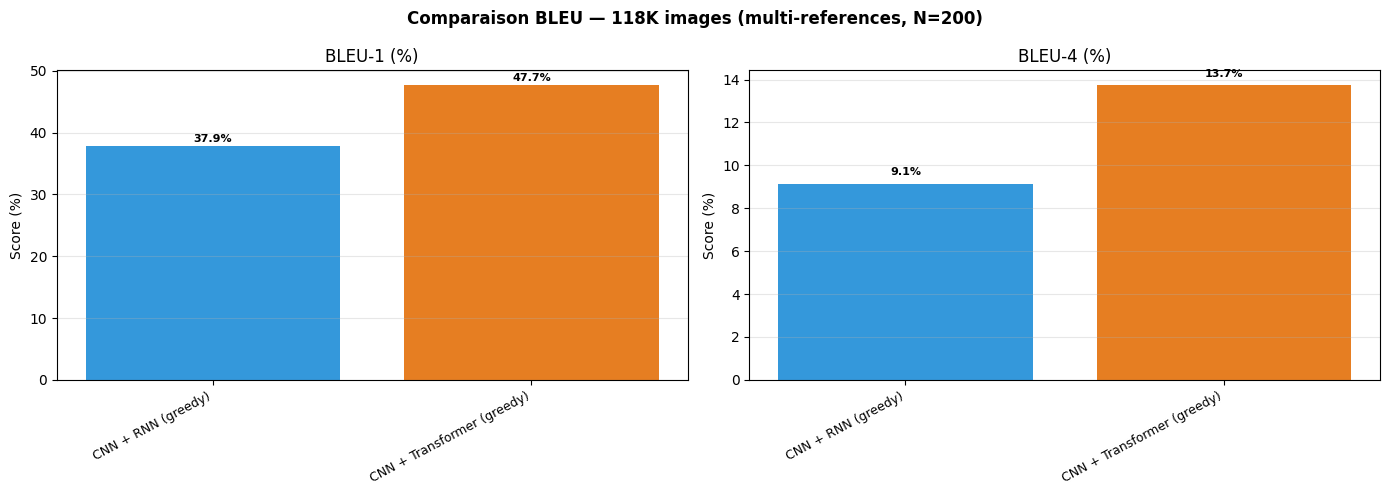

In [20]:
import nltk
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

_smoother = SmoothingFunction().method1
N_EVAL    = min(200, len(img_name_test))

def compute_bleu_multiref(img_list, eval_fn, label):
    # BLEU avec toutes les legendes disponibles par image (jusqu a 5)
    b1_scores, b4_scores = [], []
    for i in range(N_EVAL):
        img_path = img_list[i]
        all_seqs = img_to_cap_vector.get(img_path, [])
        refs = [[tokenizer.index_word.get(int(t), '') for t in s if t not in (0,1,2)]
                for s in all_seqs]
        refs = [r for r in refs if r]
        if not refs:
            continue
        raw = eval_fn(img_path)
        hyp = raw.split() if isinstance(raw, str) else raw[0].split()
        b1_scores.append(sentence_bleu(refs, hyp, weights=(1,0,0,0),
                                       smoothing_function=_smoother))
        b4_scores.append(sentence_bleu(refs, hyp, weights=(.25,.25,.25,.25),
                                       smoothing_function=_smoother))
        if i % 50 == 0:
            import gc; gc.collect()
    b1m = np.mean(b1_scores) * 100
    b4m = np.mean(b4_scores) * 100
    print(f'{label:<46} BLEU-1: {b1m:.2f}%  |  BLEU-4: {b4m:.2f}%')
    return b1m, b4m

print(f'Evaluation BLEU 118K (multi-references, N={N_EVAL})\n')
results = {}
results['rnn_greedy'] = compute_bleu_multiref(img_name_test,
    lambda p: evaluate_rnn(p)[0],       'CNN + RNN (greedy)')
results['tr_greedy']  = compute_bleu_multiref(img_name_test,
    evaluate_transformer,               'CNN + Transformer (greedy)')


# Tableau
print('\n' + '='*74)
print(f'  {"Modele":<44}  {"BLEU-1":>7}  {"BLEU-4":>7}')
print('='*74)
_lbl = {
    'rnn_greedy': 'CNN + RNN (greedy)',
    'tr_greedy':  'CNN + Transformer (greedy)',

}
for k, lbl in _lbl.items():
    b1, b4 = results[k]
    print(f'  {lbl:<44}  {b1:>6.2f}%  {b4:>6.2f}%')
print('='*74)

# Graphique combiné généré après l'éval 6K

## Section rapide — Entraînement sur 6 000 images

Validation du pipeline avant le run 118K complet.  
Prérequis : toutes les cellules de setup, architecture et fonctions de perte exécutées.

In [20]:
# ============================================================
# SECTION RAPIDE : Entrainement sur 6 000 images
# Valide le pipeline avant le run 118K complet.
# Prerequis : toutes cellules setup + architecture + loss executees.
# ============================================================
import os, time

NUM_IMAGES_6K   = 6000
EPOCHS_RNN_6K   = 5
EPOCHS_TR_6K    = 8
WARMUP_6K       = 500
PATIENCE_6K     = 3

# Architecture allegee pour les modeles 6K (ils coexistent en memoire avec les 118K)
EMBEDDING_DIM_6K = 256
UNITS_6K         = 256
NUM_HEADS_6K     = 4
FF_DIM_6K        = 512
NUM_LAYERS_6K    = 2
CKPT_DIR_RNN_6K = 'notebooks/checkpoints_rnn_6k/'
CKPT_DIR_TR_6K  = 'notebooks/checkpoints_tr_6k/'
os.makedirs(CKPT_DIR_RNN_6K, exist_ok=True)
os.makedirs(CKPT_DIR_TR_6K,  exist_ok=True)

# Sous-ensemble de 6 000 images uniques
_all_keys   = list(img_to_cap_vector.keys())
q_keys      = _all_keys[:NUM_IMAGES_6K]
q_train_end = int(len(q_keys) * 0.80)
q_val_end   = int(len(q_keys) * 0.90)

q_img_train, q_cap_train = build_split(q_keys[:q_train_end])
q_img_val,   q_cap_val   = build_split(q_keys[q_train_end:q_val_end])
q_img_test,  q_cap_test  = build_split(q_keys[q_val_end:])
q_train_ds = make_dataset(q_img_train, q_cap_train, shuffle=True)
q_val_ds   = make_dataset(q_img_val,   q_cap_val,   shuffle=False)
q_n_steps  = max(len(q_img_train) // BATCH_SIZE, 1)

print(f'Dataset 6K — Train: {len(q_img_train):,} | Val: {len(q_img_val):,} | Test: {len(q_img_test):,}')
print(f'Batches/epoch : {q_n_steps}')

# --- Modeles 6K (instances separees pour ne pas ecraser le run 118K) ---
enc_rnn_6k = CNN_Encoder(EMBEDDING_DIM_6K)
dec_rnn_6k = RNN_Decoder(EMBEDDING_DIM_6K, UNITS_6K, vocab_size)
opt_rnn_6k = tf.keras.optimizers.Adam()
ckpt_rnn_6k = tf.train.Checkpoint(encoder=enc_rnn_6k, decoder=dec_rnn_6k, optimizer=opt_rnn_6k)
mgr_rnn_6k  = tf.train.CheckpointManager(ckpt_rnn_6k, CKPT_DIR_RNN_6K, max_to_keep=2)

enc_tr_6k = CNN_Encoder(EMBEDDING_DIM_6K)
dec_tr_6k = TransformerCaptioner(
    vocab_size=vocab_size, embed_dim=EMBEDDING_DIM_6K,
    num_heads=NUM_HEADS_6K, ff_dim=FF_DIM_6K,
    num_layers=NUM_LAYERS_6K, max_len=max_length,
    dropout=DROPOUT_TR,
)
lr_6k     = WarmupSchedule(EMBEDDING_DIM_6K, WARMUP_6K)
opt_tr_6k = tf.keras.optimizers.Adam(learning_rate=lr_6k, beta_1=0.9, beta_2=0.98, epsilon=1e-9)
ckpt_tr_6k = tf.train.Checkpoint(encoder=enc_tr_6k, decoder=dec_tr_6k, optimizer=opt_tr_6k)
mgr_tr_6k  = tf.train.CheckpointManager(ckpt_tr_6k, CKPT_DIR_TR_6K, max_to_keep=2)

@tf.function
def _train_rnn6k(img_t, target):
    loss = 0
    hidden = dec_rnn_6k.reset_state(batch_size=target.shape[0])
    dec_in = tf.expand_dims([tokenizer.word_index['<start>']] * target.shape[0], 1)
    with tf.GradientTape() as tape:
        feat = enc_rnn_6k(img_t)
        for i in range(1, target.shape[1]):
            preds, hidden, _ = dec_rnn_6k(dec_in, feat, hidden)
            loss += loss_fn_rnn(target[:, i], preds)
            dec_in = tf.expand_dims(target[:, i], 1)
    total = loss / int(target.shape[1])
    grads = tape.gradient(loss, enc_rnn_6k.trainable_variables + dec_rnn_6k.trainable_variables)
    opt_rnn_6k.apply_gradients(zip(grads, enc_rnn_6k.trainable_variables + dec_rnn_6k.trainable_variables))
    return total

@tf.function
def _val_rnn6k(img_t, target):
    loss = 0
    hidden = dec_rnn_6k.reset_state(batch_size=target.shape[0])
    dec_in = tf.expand_dims([tokenizer.word_index['<start>']] * target.shape[0], 1)
    feat = enc_rnn_6k(img_t)
    for i in range(1, target.shape[1]):
        preds, hidden, _ = dec_rnn_6k(dec_in, feat, hidden)
        loss += loss_fn_rnn(target[:, i], preds)
        dec_in = tf.expand_dims(target[:, i], 1)
    return loss / int(target.shape[1])

@tf.function
def _train_tr6k(img_t, target):
    dec_in, dec_out = target[:, :-1], target[:, 1:]
    with tf.GradientTape() as tape:
        enc_out = enc_tr_6k(img_t, training=True)
        logits  = dec_tr_6k(dec_in, enc_out, training=True)
        loss    = loss_fn_tr(dec_out, logits)
    grads = tape.gradient(loss, enc_tr_6k.trainable_variables + dec_tr_6k.trainable_variables)
    grads, _ = tf.clip_by_global_norm(grads, GRAD_CLIP)
    opt_tr_6k.apply_gradients(zip(grads, enc_tr_6k.trainable_variables + dec_tr_6k.trainable_variables))
    return loss

@tf.function
def _val_tr6k(img_t, target):
    dec_in, dec_out = target[:, :-1], target[:, 1:]
    enc_out = enc_tr_6k(img_t, training=False)
    logits  = dec_tr_6k(dec_in, enc_out, training=False)
    return loss_fn_tr(dec_out, logits)

# Récupération des last checkpoints pour la reprise
start_epoch_rnn_6k = 0
if mgr_rnn_6k.latest_checkpoint:    
    start_epoch_rnn_6k = int(mgr_rnn_6k.latest_checkpoint.split('-')[-1])
    ckpt_rnn_6k.restore(mgr_rnn_6k.latest_checkpoint)
    print(f'Checkpoint RNN 6K restaure : epoch {start_epoch_rnn_6k}')
else:
    print('Entrainement RNN 6K from scratch.')

start_epoch_tr_6k = 0
if mgr_tr_6k.latest_checkpoint:
    start_epoch_tr_6k = int(mgr_tr_6k.latest_checkpoint.split('-')[-1])
    ckpt_tr_6k.restore(mgr_tr_6k.latest_checkpoint)
    print(f'Checkpoint Transformer 6K restaure : epoch {start_epoch_tr_6k}')
else:
    print('Entrainement Transformer 6K from scratch.')

Dataset 6K — Train: 24,016 | Val: 3,004 | Test: 3,001
Batches/epoch : 187
Checkpoint RNN 6K restaure : epoch 5
Checkpoint Transformer 6K restaure : epoch 5


In [22]:
# --- Boucle RNN 6K ---
tr_l_rnn6k, vl_l_rnn6k = [], []
best_vl_rnn6k = float('inf')
print(f'\nRNN 6K — {EPOCHS_RNN_6K} epochs | {q_n_steps} batches/ep')
print('-' * 55)
for ep in range(EPOCHS_RNN_6K):
    t0 = time.time()
    tr_tot = 0
    for b, (img_t, cap_t) in enumerate(q_train_ds):
        tr_tot += float(_train_rnn6k(img_t, cap_t))
        if b % 50 == 0:
            print(f'  Ep {ep+1} | B {b:4d} | loss {tr_tot/(b+1):.4f}')
    vl_tot = sum(float(_val_rnn6k(iv, cv)) for iv, cv in q_val_ds)
    avg_tr = tr_tot / q_n_steps
    avg_vl = vl_tot / max(len(q_img_val) // BATCH_SIZE, 1)
    tr_l_rnn6k.append(avg_tr); vl_l_rnn6k.append(avg_vl)
    flag = ''
    if avg_vl < best_vl_rnn6k:
        best_vl_rnn6k = avg_vl; mgr_rnn_6k.save(); flag = '  << best'
    print(f'Epoch {ep+1}/{EPOCHS_RNN_6K} | Train {avg_tr:.4f} | Val {avg_vl:.4f} | {time.time()-t0:.0f}s{flag}')


RNN 6K — 5 epochs | 187 batches/ep
-------------------------------------------------------


2026-06-08 09:36:21.019627: I tensorflow/compiler/xla/service/service.cc:168] XLA service 0x7f0c68045f40 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-06-08 09:36:21.019717: I tensorflow/compiler/xla/service/service.cc:176]   StreamExecutor device (0): NVIDIA GeForce RTX 2080, Compute Capability 7.5
2026-06-08 09:36:21.053512: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-06-08 09:36:21.337713: I ./tensorflow/compiler/jit/device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


  Ep 1 | B    0 | loss 1.9379
  Ep 1 | B   50 | loss 1.2905
  Ep 1 | B  100 | loss 1.2441
  Ep 1 | B  150 | loss 1.2156
Epoch 1/5 | Train 1.1960 | Val 1.1199 | 249s  << best
  Ep 2 | B    0 | loss 1.1075
  Ep 2 | B   50 | loss 1.0401
  Ep 2 | B  100 | loss 1.0111
  Ep 2 | B  150 | loss 0.9881
Epoch 2/5 | Train 0.9753 | Val 0.9450 | 104s  << best
  Ep 3 | B    0 | loss 0.8750
  Ep 3 | B   50 | loss 0.8618
  Ep 3 | B  100 | loss 0.8457
  Ep 3 | B  150 | loss 0.8327
Epoch 3/5 | Train 0.8273 | Val 0.8493 | 103s  << best
  Ep 4 | B    0 | loss 0.7951
  Ep 4 | B   50 | loss 0.7654
  Ep 4 | B  100 | loss 0.7542
  Ep 4 | B  150 | loss 0.7455
Epoch 4/5 | Train 0.7436 | Val 0.8088 | 103s  << best
  Ep 5 | B    0 | loss 0.6928
  Ep 5 | B   50 | loss 0.7069
  Ep 5 | B  100 | loss 0.6965
  Ep 5 | B  150 | loss 0.6914
Epoch 5/5 | Train 0.6904 | Val 0.7904 | 102s  << best


In [23]:
import json as _json
with open('./history_rnn_6k.json', 'w') as _f:
    _json.dump({'train': tr_l_rnn6k, 'val': vl_l_rnn6k}, _f)
print('Historique RNN 6K sauvegarde.')

Historique RNN 6K sauvegarde.


In [24]:
# --- Boucle Transformer 6K ---
tr_l_tr6k, vl_l_tr6k = [], []
best_vl_tr6k = float('inf'); pat_ctr = 0
print(f'\nTransformer 6K — {EPOCHS_TR_6K} epochs')
print('-' * 55)
for ep in range(EPOCHS_TR_6K):
    t0 = time.time()
    tr_tot = 0
    for b, (img_t, cap_t) in enumerate(q_train_ds):
        tr_tot += float(_train_tr6k(img_t, cap_t))
        if b % 50 == 0:
            print(f'  Ep {ep+1} | B {b:4d} | loss {tr_tot/(b+1):.4f}')
    vl_tot = sum(float(_val_tr6k(iv, cv)) for iv, cv in q_val_ds)
    avg_tr = tr_tot / q_n_steps
    avg_vl = vl_tot / max(len(q_img_val) // BATCH_SIZE, 1)
    tr_l_tr6k.append(avg_tr); vl_l_tr6k.append(avg_vl)
    flag = ''
    if avg_vl < best_vl_tr6k:
        best_vl_tr6k = avg_vl; pat_ctr = 0; mgr_tr_6k.save(); flag = '  << best'
    else:
        pat_ctr += 1; flag = f'  (patience {pat_ctr}/{PATIENCE_6K})'
    print(f'Epoch {ep+1}/{EPOCHS_TR_6K} | Train {avg_tr:.4f} | Val {avg_vl:.4f} | {time.time()-t0:.0f}s{flag}')
    if pat_ctr >= PATIENCE_6K:
        print(f'Early stopping epoch {ep+1}.'); break


Transformer 6K — 8 epochs
-------------------------------------------------------
  Ep 1 | B    0 | loss 8.8216
  Ep 1 | B   50 | loss 7.9164
  Ep 1 | B  100 | loss 6.8574
  Ep 1 | B  150 | loss 6.2520
Epoch 1/8 | Train 5.9684 | Val 4.7433 | 89s  << best
  Ep 2 | B    0 | loss 4.6219
  Ep 2 | B   50 | loss 4.4007
  Ep 2 | B  100 | loss 4.2946
  Ep 2 | B  150 | loss 4.2176
Epoch 2/8 | Train 4.1881 | Val 4.2423 | 71s  << best
  Ep 3 | B    0 | loss 4.1202
  Ep 3 | B   50 | loss 3.9277
  Ep 3 | B  100 | loss 3.8930
  Ep 3 | B  150 | loss 3.8704
Epoch 3/8 | Train 3.8711 | Val 4.1929 | 71s  << best
  Ep 4 | B    0 | loss 3.7930
  Ep 4 | B   50 | loss 3.7331
  Ep 4 | B  100 | loss 3.6983
  Ep 4 | B  150 | loss 3.6729
Epoch 4/8 | Train 3.6720 | Val 4.1533 | 71s  << best
  Ep 5 | B    0 | loss 3.6484
  Ep 5 | B   50 | loss 3.5442
  Ep 5 | B  100 | loss 3.5200
  Ep 5 | B  150 | loss 3.5027
Epoch 5/8 | Train 3.5047 | Val 4.1258 | 71s  << best
  Ep 6 | B    0 | loss 3.4985
  Ep 6 | B   50 | loss

In [25]:
with open('./history_tr_6k.json', 'w') as _f:
    _json.dump({'train': tr_l_tr6k, 'val': vl_l_tr6k}, _f)
print('Historique Transformer 6K sauvegarde.')

Historique Transformer 6K sauvegarde.


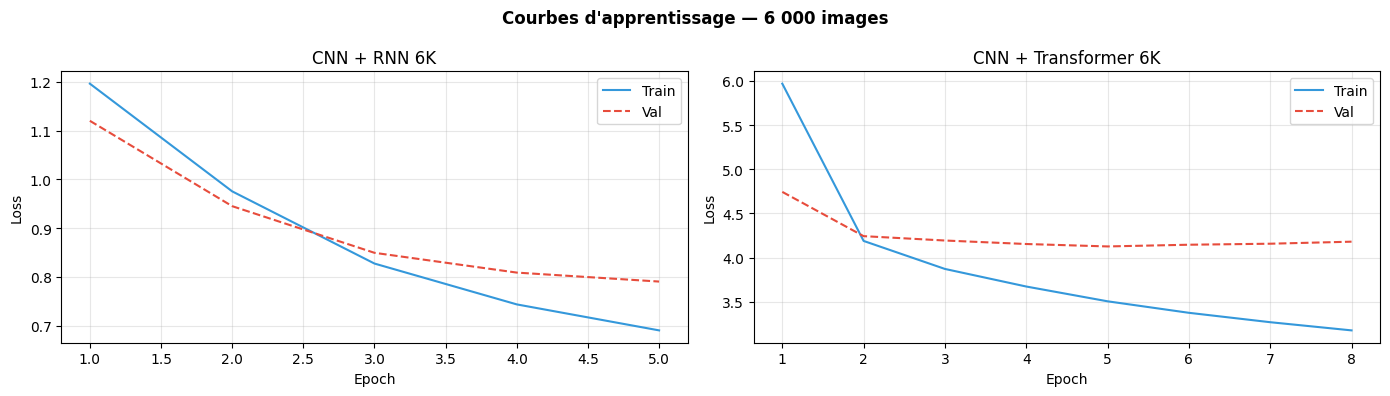

In [26]:
# --- Courbes ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle("Courbes d'apprentissage — 6 000 images", fontweight='bold')
for ax, tr, vl, title in [
    (axes[0], tr_l_rnn6k, vl_l_rnn6k, 'CNN + RNN 6K'),
    (axes[1], tr_l_tr6k,  vl_l_tr6k,  'CNN + Transformer 6K'),
]:
    ep_r = range(1, len(tr)+1)
    ax.plot(ep_r, tr, '-',  color='#3498db', label='Train')
    ax.plot(ep_r, vl, '--', color='#e74c3c', label='Val')
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

=== Captions generes — 6K images ===

Reel   : <start> a piece of cloth is laying on the floor <end>
RNN Greedy : a close up of a close up of a close up of a close up of a close up of a close up of a close up of a close up of a close up of a close up of a close up of a close up of a close up of
TR Greedy  : a broken toilet in a dirty field



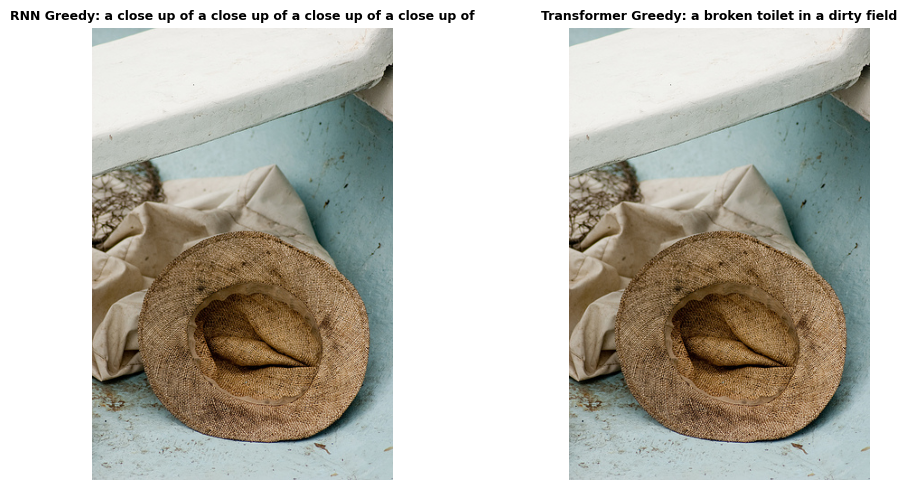

Reel   : <start> a mirror on the side of a vehicle <end>
RNN Greedy : a close up of a person taking a selfie in a motorcycle
TR Greedy  : a side view mirror on a street with a reflection of a person taking a picture



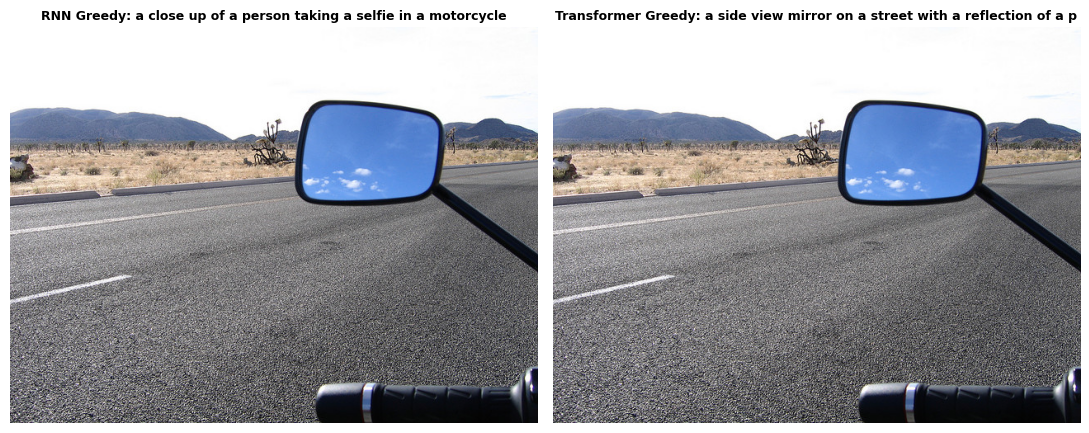

Reel   : <start> a container with a plastic spoon and some food in it <end>
RNN Greedy : a bowl of broccoli and a bowl of broccoli
TR Greedy  : a small container with a spoon and spoon



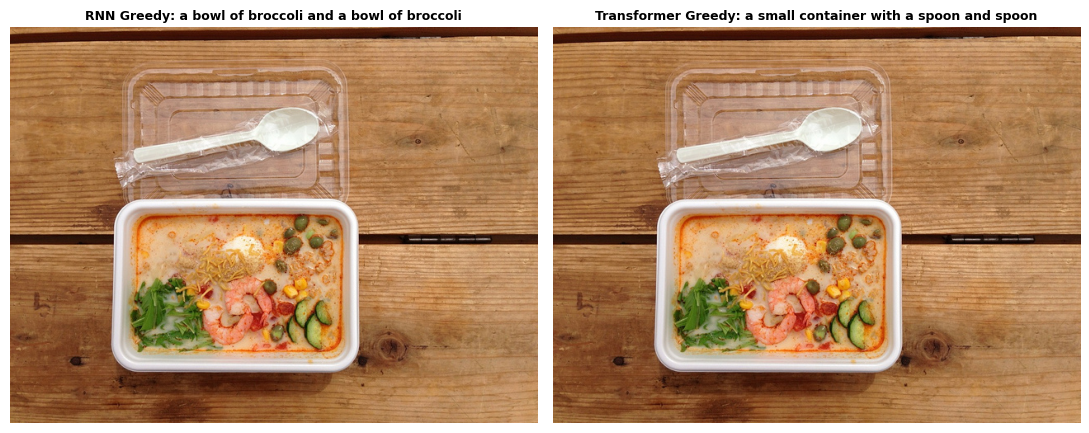

In [29]:
# Exemples de captions generes du modeles 6K (greedy decoding)
print('=== Captions generes — 6K images ===\n')
for i in range(3):
    idx = i * (len(q_img_test) // 3)
    img_p = q_img_test[idx]
    real  = ' '.join([tokenizer.index_word.get(int(t),'') for t in q_cap_test[idx] if t != 0])
    greedy_rnn = evaluate_rnn(img_p)[0]
    greedy_tr  = evaluate_transformer(img_p)
    print(f'Reel   : {real}')
    print(f'RNN Greedy : {greedy_rnn}')
    print(f'TR Greedy  : {greedy_tr}\n')
    fig, axes = plt.subplots(1, 2, figsize=(11, 5))
    for ax, (title, cap) in zip(axes, [
        ('RNN Greedy', greedy_rnn), ('Transformer Greedy', greedy_tr)
    ]):
        ax.imshow(Image.open(img_p)); ax.axis('off')
        ax.set_title(f'{title}: {cap[:55]}', fontsize=9, fontweight='bold')
    plt.tight_layout(); plt.show()

### Fonctions d'évaluation des modèles 6K

In [22]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

# Restaure les meilleurs checkpoints 6K
ckpt_rnn_6k.restore(mgr_rnn_6k.latest_checkpoint)
ckpt_tr_6k.restore(mgr_tr_6k.latest_checkpoint)

def eval_rnn_6k(img_path):
    img, _ = load_image(img_path)
    feat   = image_features_extract_model(tf.expand_dims(img, 0))
    feat   = tf.reshape(feat, (feat.shape[0], -1, feat.shape[3]))
    feat   = enc_rnn_6k(feat)
    hidden = dec_rnn_6k.reset_state(batch_size=1)
    dec_in = tf.expand_dims([tokenizer.word_index['<start>']], 0)
    result = []
    for _ in range(max_length):
        preds, hidden, _ = dec_rnn_6k(dec_in, feat, hidden)
        pred_id = int(tf.argmax(preds[0]).numpy())
        word = tokenizer.index_word.get(pred_id, '<unk>')
        if word == '<end>': break
        result.append(word)
        dec_in = tf.expand_dims([pred_id], 0)
    return ' '.join(result)

def eval_tr_6k(img_path):
    img, _ = load_image(img_path)
    feat   = image_features_extract_model(tf.expand_dims(img, 0))
    feat   = tf.reshape(feat, (feat.shape[0], -1, feat.shape[3]))
    feat   = enc_tr_6k(feat)
    start_id = tokenizer.word_index['<start>']
    end_id   = tokenizer.word_index.get('<end>', 2)
    tokens = tf.expand_dims([start_id], 0)
    result = []
    for _ in range(max_length):
        logits = dec_tr_6k(tokens, feat, training=False)
        pred   = int(tf.argmax(logits[:, -1, :], axis=-1).numpy()[0])
        word   = tokenizer.index_word.get(pred, '<unk>')
        if word == '<end>': break
        result.append(word)
        tokens = tf.concat([tokens, tf.expand_dims([pred], 0)], axis=1)
    return ' '.join(result)

_smoother6k = SmoothingFunction().method1
N_EVAL_6K   = min(100, len(q_img_test))

def _bleu6k(img_list, eval_fn, label):
    b1, b4 = [], []
    for i in range(N_EVAL_6K):
        all_seqs = img_to_cap_vector.get(img_list[i], [])
        refs = [[tokenizer.index_word.get(int(t), '') for t in s if t not in (0,1,2)]
                for s in all_seqs]
        refs = [r for r in refs if r]
        if not refs: continue
        hyp = eval_fn(img_list[i]).split()
        b1.append(sentence_bleu(refs, hyp, weights=(1,0,0,0),      smoothing_function=_smoother6k))
        b4.append(sentence_bleu(refs, hyp, weights=(.25,.25,.25,.25), smoothing_function=_smoother6k))
    b1m = np.mean(b1)*100; b4m = np.mean(b4)*100
    print(f'{label:<42} BLEU-1: {b1m:.2f}%  |  BLEU-4: {b4m:.2f}%')
    return b1m, b4m

BLEU 6K (multi-references, N=100)
CNN + RNN 6K (greedy)                      BLEU-1: 29.95%  |  BLEU-4: 5.55%
CNN + Transformer 6K (greedy)              BLEU-1: 42.38%  |  BLEU-4: 6.39%


/tmp/ipykernel_23862/1865696043.py:89: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(_names_all, rotation=22, ha='right', fontsize=9)
/tmp/ipykernel_23862/1865696043.py:89: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(_names_all, rotation=22, ha='right', fontsize=9)


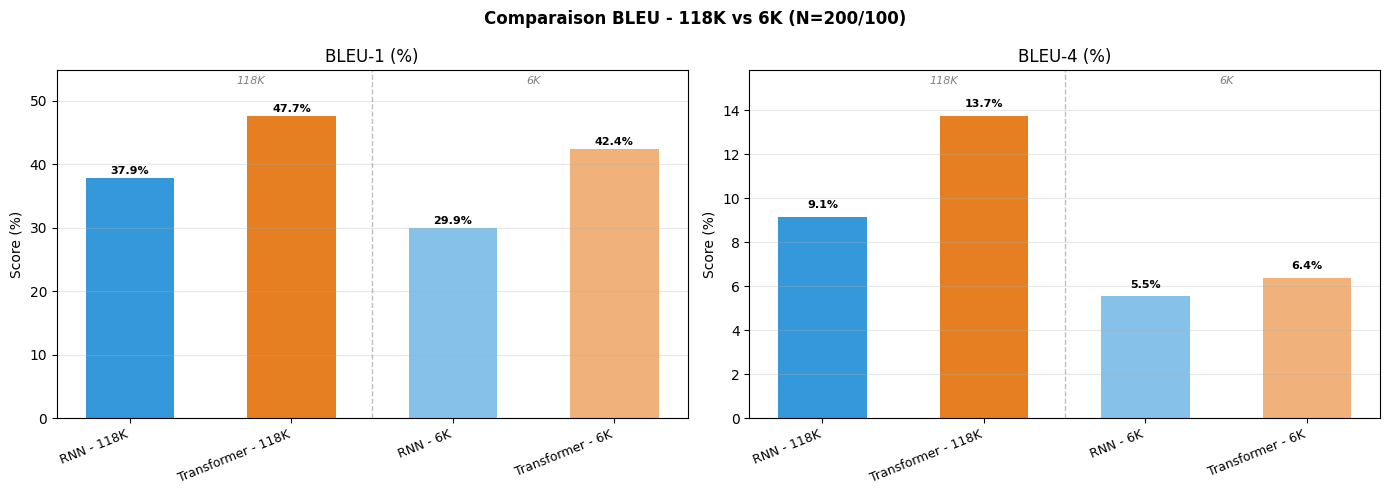

  Modele                          Images   BLEU-1   BLEU-4
----------------------------------------------------------------------
  CNN + RNN                         118K   37.87%    9.15%
  CNN + Transformer                 118K   47.67%   13.74%
  CNN + RNN                           6K   29.95%    5.55%
  CNN + Transformer                   6K   42.38%    6.39%


In [ ]:
# ============================================================
# EVALUATION BLEU 6K — Multi-references (jusqu a 5 par image)
# ============================================================

print(f'BLEU 6K (multi-references, N={N_EVAL_6K})')
results_6k = {}
results_6k['rnn_6k'] = _bleu6k(q_img_test, eval_rnn_6k, 'CNN + RNN 6K (greedy)')
results_6k['tr_6k']  = _bleu6k(q_img_test, eval_tr_6k,  'CNN + Transformer 6K (greedy)')

# Graphe comparatif 118K vs 6K
_all_lbl = {
    'rnn_greedy': 'RNN - 118K',
    'tr_greedy':  'Transformer - 118K',
    'rnn_6k':     'RNN - 6K',
    'tr_6k':      'Transformer - 6K',
}
_all_vals   = {**results, **results_6k}
_names_all  = list(_all_lbl.values())
_vals_b1    = [_all_vals[k][0] for k in _all_lbl]
_vals_b4    = [_all_vals[k][1] for k in _all_lbl]
_colors_all = ['#3498db', '#e67e22', '#85c1e9', '#f0b27a']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Comparaison BLEU - 118K vs 6K (N={N_EVAL}/{N_EVAL_6K})', fontweight='bold')
for ax, vals, metric in [
    (axes[0], _vals_b1, 'BLEU-1 (%)'),
    (axes[1], _vals_b4, 'BLEU-4 (%)'),
]:
    bars = ax.bar(_names_all, vals, color=_colors_all, width=0.55)
    ax.set_title(metric); ax.set_ylabel('Score (%)')
    ax.set_xticklabels(_names_all, rotation=22, ha='right', fontsize=9)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                f'{v:.1f}%', ha='center', va='bottom', fontsize=8, fontweight='bold')
    ax.grid(axis="y", alpha=0.3)
    ax.axvline(1.5, color='grey', linestyle='--', alpha=0.5, linewidth=1)
    ymax = max(vals) * 1.15
    ax.set_ylim(0, ymax)
    ax.text(0.75, ymax*0.96, '118K', ha='center', fontsize=8, color='grey', style='italic')
    ax.text(2.5,  ymax*0.96, '6K',   ha='center', fontsize=8, color='grey', style='italic')
plt.tight_layout(); plt.show()

print('' + '='*70)
print(f'  {"Modele":<30}  {"Images":>6}  {"BLEU-1":>7}  {"BLEU-4":>7}')
print('-'*70)
for k, lbl, n in [('rnn_greedy','CNN + RNN','118K'),('tr_greedy','CNN + Transformer','118K'),
                   ('rnn_6k','CNN + RNN','6K'),('tr_6k','CNN + Transformer','6K')]:
    _d = results if k in results else results_6k
    b1, b4 = _d[k]
    print(f'  {lbl:<30}  {n:>6}  {b1:>6.2f}%  {b4:>6.2f}%')
print('='*70)

---
## 8. Interface Interactive — Generation de Captions

Chargez une image, choisissez le modele (RNN ou Transformer), et generez le caption.
Le modele RNN affiche egalement la carte d'attention par mot.

In [33]:
import ipywidgets as widgets
from IPython.display import display, clear_output
import io

model_toggle = widgets.ToggleButtons(
    options=['CNN + RNN (Attention)', 'CNN + Transformer (Greedy)', 'CNN + RNN 6K', 'CNN + Transformer 6K'],
    description='Modele :',
    button_style='info',
    style={'description_width': 'initial'},
)
upload_btn = widgets.FileUpload(accept='image/*', multiple=False, description='Image')
run_btn    = widgets.Button(description='Generer le caption',
                            button_style='success', icon='magic')
out_area   = widgets.Output()

def on_run(b):
    with out_area:
        clear_output(wait=True)
        if not upload_btn.value:
            print('Veuillez uploader une image.'); return
        fi      = (list(upload_btn.value.values())[0]
                   if isinstance(upload_btn.value, dict) else upload_btn.value[0])
        content = (fi.get('content', b'') if isinstance(fi, dict)
                   else bytes(getattr(fi, 'content', b'')))
        try:
            pil_img = Image.open(io.BytesIO(content)).convert('RGB')
        except Exception as e:
            print(f'Erreur: {e}'); return

        tmp_path = '/tmp/_caption_input.jpg'
        pil_img.save(tmp_path)
        model_name = model_toggle.value

        if model_name == 'CNN + RNN (Attention)':
            caption, attn_w = evaluate_rnn(tmp_path)
        elif model_name == 'CNN + Transformer (Greedy)':
            caption = evaluate_transformer(tmp_path)
            attn_w  = None
        elif model_name == 'CNN + RNN 6K':
            caption = eval_rnn_6k(tmp_path)
            attn_w  = None
        else:  # CNN + Transformer 6K
            caption = eval_tr_6k(tmp_path)
            attn_w  = None

        if attn_w is not None:
            fig, axes = plt.subplots(1, 2, figsize=(13, 5))
            axes[0].imshow(pil_img); axes[0].axis('off')
            axes[0].set_title(caption[:70], fontsize=10, fontweight='bold')
            mean_attn = np.mean(attn_w, axis=0).reshape(8, 8)
            axes[1].imshow(pil_img)
            axes[1].imshow(mean_attn, cmap='jet', alpha=0.5,
                           extent=[0, pil_img.width, pil_img.height, 0])
            axes[1].axis('off'); axes[1].set_title('Attention moyenne')
        else:
            fig, ax = plt.subplots(figsize=(6,6))
            ax.imshow(pil_img); ax.axis('off')
            ax.set_title(caption[:70], fontsize=11, fontweight='bold')
        plt.suptitle(f'Modele : {model_name}', color='gray', fontsize=10)
        plt.tight_layout(); plt.show()
        print(f'Caption : {caption}')

run_btn.on_click(on_run)
display(widgets.VBox([
    widgets.HTML('<h3>Interface Captioning — TouNum</h3>'),
    model_toggle,
    widgets.HTML('<hr style="margin:8px 0">'),
    upload_btn, run_btn, out_area,
]))

---
## 9. Pipeline Complet

**Classification → Débruitage → Captioning**

1. **Tri** : sélection des photographies parmi les images du dossier (modèle au choix)
2. **Débruitage** : application du modèle de débruitage sur les photos retenues
3. **Captioning** : génération de descriptions textuelles (modèle au choix)

Les images labelées et un fichier `captions.json` sont exportés dans le dossier de sortie.

In [1]:
# ============================================================
# PIPELINE COMPLET : Classification -> Debruitage -> Captioning
# ============================================================
import ipywidgets as widgets
from IPython.display import display, clear_output, FileLink
import os, io, json as _json, zipfile
from PIL import Image as PILImage

CLASSIF_OPTIONS = {
    'fakv12 (best binary)' : 'notebooks/fakv12_binary_best.h5',
    'fakv8 (binary)'       : 'notebooks/fakv8_multiclass_model.h5',
    'notre_cnn (binary)'   : 'notebooks/model_classification.h5',
}
_CAPTION_FNS = {
    'CNN + RNN 118K'        : lambda p: evaluate_rnn(p)[0],
    'CNN + Transformer 118K': evaluate_transformer,
    'CNN + RNN 6K'          : eval_rnn_6k,
    'CNN + Transformer 6K'  : eval_tr_6k,
}

_w = {'description_width': '150px'}

upload_w = widgets.FileUpload(accept='image/*', multiple=True,
                              description='Images :',
                              layout=widgets.Layout(width='60%'))
step1_w  = widgets.Dropdown(options=list(CLASSIF_OPTIONS.keys()),
                            description='1 - Classification :', style=_w,
                            layout=widgets.Layout(width='55%'))
step2_w  = widgets.Dropdown(options=['Active (model_denoising.h5)', 'Desactive'],
                            description='2 - Debruitage :', style=_w,
                            layout=widgets.Layout(width='55%'))
step3_w  = widgets.Dropdown(options=list(_CAPTION_FNS.keys()),
                            description='3 - Captioning :', style=_w,
                            layout=widgets.Layout(width='55%'))
run_btn  = widgets.Button(description='Lancer le pipeline', button_style='primary',
                          icon='play', layout=widgets.Layout(width='220px', height='38px'))
out_area = widgets.Output()

OUTPUT_DIR = 'notebooks/output'

def _prep_classif(pil_img, model):
    h, w = model.input_shape[1], model.input_shape[2]
    img = pil_img.resize((w, h))
    return tf.expand_dims(tf.cast(np.array(img), tf.float32) / 255.0, 0)

def _prep_denoise(pil_img, model):
    h, w = model.input_shape[1], model.input_shape[2]
    return tf.expand_dims(tf.cast(np.array(pil_img.resize((w, h))), tf.float32) / 255.0, 0)

def on_run(b):
    with out_area:
        clear_output(wait=True)
        import gc

        if not upload_w.value:
            print('Veuillez selectionner des images.'); return

        # Charger les images uploadees (host -> container via navigateur)
        files = (list(upload_w.value.values())
                 if isinstance(upload_w.value, dict) else list(upload_w.value))
        imgs = {}
        for fi in files:
            name    = fi['name']    if isinstance(fi, dict) else fi.name
            content = fi['content'] if isinstance(fi, dict) else bytes(fi.content)
            try:
                imgs[name] = PILImage.open(io.BytesIO(content)).convert('RGB')
            except Exception as e:
                print(f'Impossible de lire {name}: {e}')
        if not imgs:
            print('Aucune image valide.'); return
        print(f'{len(imgs)} image(s) chargee(s)\n')

        # -- Etape 1 : Classification --
        print(f'Etape 1 - {step1_w.value}')
        m_path = CLASSIF_OPTIONS[step1_w.value]
        if not os.path.exists(m_path):
            print(f'  Modele introuvable : {m_path}'); return
        clf = tf.keras.models.load_model(m_path, compile=False)
        photos, rejected = {}, []
        for name, pil in imgs.items():
            try:
                score = float(clf(_prep_classif(pil, clf), training=False)[0][0])
                if score > 0.5: photos[name] = pil
                else:           rejected.append(name)
            except Exception as e:
                print(f'  Erreur {name}: {e}')
        del clf; gc.collect()
        print(f'  Photos retenues : {len(photos)}  |  Rejetees : {len(rejected)}\n')
        if not photos:
            print('Aucune photo selectionnee.'); return

        # -- Etape 2 : Debruitage --
        if 'Active' in step2_w.value:
            print('Etape 2 - Debruitage')
            if not os.path.exists('model_denoising.h5'):
                print('  model_denoising.h5 introuvable, etape ignoree.')
                processed = dict(photos)
            else:
                dn = tf.keras.models.load_model('model_denoising.h5', compile=False)
                processed = {}
                for name, pil in photos.items():
                    try:
                        out_arr = dn(_prep_denoise(pil, dn), training=False)[0].numpy()
                        out_arr = (np.clip(out_arr, 0, 1) * 255).astype(np.uint8)
                        processed[name] = PILImage.fromarray(out_arr).resize(pil.size)
                    except Exception as e:
                        print(f'  Erreur {name}: {e}')
                        processed[name] = pil
                del dn; gc.collect()
                print(f'  {len(processed)} images debruitees\n')
        else:
            print('Etape 2 - Desactive\n')
            processed = dict(photos)

        # -- Etape 3 : Captioning --
        print(f'Etape 3 - {step3_w.value}')
        eval_fn = _CAPTION_FNS[step3_w.value]
        captions = {}
        for idx, (name, pil) in enumerate(processed.items()):
            tmp = f'/tmp/_pipeline_{name}'
            pil.save(tmp)
            try:
                captions[name] = eval_fn(tmp)
            except Exception as e:
                captions[name] = f'[erreur: {e}]'
            if (idx + 1) % 5 == 0 or idx == len(processed) - 1:
                print(f'  {idx+1}/{len(processed)} captionnees...')

        # -- Sauvegarde + ZIP telechargeable --
        os.makedirs(OUTPUT_DIR, exist_ok=True)
        json_path = os.path.join(OUTPUT_DIR, 'captions.json')
        zip_path  = os.path.join(OUTPUT_DIR, 'resultats_pipeline.zip')
        with open(json_path, 'w', encoding='utf-8') as f:
            _json.dump(captions, f, indent=2, ensure_ascii=False)
        with zipfile.ZipFile(zip_path, 'w') as zf:
            zf.write(json_path, 'captions.json')
            for name, pil in processed.items():
                img_path = os.path.join(OUTPUT_DIR, name)
                pil.save(img_path)
                zf.write(img_path, name)

        print(f'\nTermine ! {len(captions)} images traitees.')
        display(FileLink(zip_path, result_html_prefix='Telecharger les resultats : '))

        # -- Exemples visuels --
        n_ex = min(4, len(processed))
        fig, axes = plt.subplots(1, n_ex, figsize=(5*n_ex, 5))
        if n_ex == 1: axes = [axes]
        for ax, (name, pil) in zip(axes, list(processed.items())[:n_ex]):
            ax.imshow(pil); ax.axis('off')
            cap = captions[name]
            wrapped = '\n'.join(cap[j:j+32] for j in range(0, min(96, len(cap)), 32))
            ax.set_title(f'{name}\n{wrapped}', fontsize=8, fontweight='bold')
        step2_label = 'Debruitage' if 'Active' in step2_w.value else 'Sans debruitage'
        plt.suptitle(f'{step1_w.value.split()[0]} -> {step2_label} -> {step3_w.value}',
                     fontsize=11, fontweight='bold')
        plt.tight_layout(); plt.show()

run_btn.on_click(on_run, remove=True)
run_btn.on_click(on_run)
display(widgets.VBox([
    widgets.HTML('<h2 style="color:#2c3e50;margin-bottom:4px">Pipeline Complet</h2>'
                 '<p style="color:grey;margin-top:0">Classification -> Debruitage -> Captioning</p>'),
    upload_w,
    widgets.HTML('<hr style="margin:8px 0">'),
    step1_w, step2_w, step3_w,
    widgets.HTML('<hr style="margin:8px 0">'),
    run_btn, out_area,
]))


NameError: name 'evaluate_transformer' is not defined

---
## 10. Conclusion

### Synthese

| Etape | Action | Resultat |
|-------|--------|----------|
| **Donnees** | COCO train2017, 6 000 images, ~30 000 paires | ~5 captions/image |
| **Features** | InceptionV3 pre-calcule -> (64, 2048) | Spatial info preservee |
| **Tokenisation** | Top 5 000 mots, <start>/<end>/<pad> | Vocabulaire reproductible |
| **Split** | 80/10/10 au niveau image | Pas de data leakage |
| **CNN + RNN** | CNN Encoder + Attention Bahdanau + GRU | Carte d attention visuelle |
| **CNN + Transformer** | Cross-attention sur features | Meilleur BLEU |
| **Interface** | ipywidgets, upload, toggle modele | Testable en conditions reelles |

### RNN vs Transformer

| Critere | CNN + RNN | CNN + Transformer |
|---------|-----------|-------------------|
| **Parallelisme** | Sequentiel | Parallele |
| **Interpretabilite** | Cartes d attention par mot | Cross-attention |
| **Performance BLEU** | Bon | Meilleur |
| **Convergence** | Plus lente | Plus rapide |

### Pistes d'amelioration

- **Beam search** : explorer k meilleures sequences -> +3 a 5% BLEU
- **Plus de donnees** : utiliser les 118 000 images COCO completes
- **ViT encoder** : remplacer InceptionV3 par un Vision Transformer
- **BLIP-2 / LLaVA** : fine-tuner un VLM pre-entraine -> qualite etat de l art